In [95]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import os
import copy as cp
import matplotlib.pyplot as plt
import numpy as np
import pickle
import pandas as pd
import zeus
import toml
from types import SimpleNamespace

import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.ticker import LinearLocator, MultipleLocator, AutoMinorLocator, MaxNLocator

import alfred.KSZ
import alfred.surveys
import alfred.utils as utils

from catwoman.shelter import Cat
from alfred.emulator import kemu
from alfred.parameters import *
from alfred.astrofit import *


2025-11-14 12:50:21.985190: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763121022.009392 2821083 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763121022.017128 2821083 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763121022.038104 2821083 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763121022.038137 2821083 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763121022.038140 2821083 computation_placer.cc:177] computation placer alr

parsing /data/cluster/emc-brid/Datasets/LoReLi/spectra/kSZ/LoReLi/nells30_v5 ...
6797 sims available
Now on 0 run...
Now on 1 run...
Now on 2 run...
Now on 3 run...
Now on 4 run...


In [3]:
plt.rcParams.update({
    "text.usetex": True,  # Use LaTeX for rendering
    'font.size': 13,
    "font.family": "serif",  # Use serif font
    "font.serif": ["Computer Modern Roman"],  # LaTeX's default font
})

# Introduction

This notebook contains all the code necessary to reproduce the plots of the paper

In [96]:
data = np.load("/data/cluster/emc-brid/Datasets/LoReLi/inference/productionruns8_addhksz_checkbias/CMB-HD/noiseless/data.npz")
data.keys()

KeysView(NpzFile '/data/cluster/emc-brid/Datasets/LoReLi/inference/productionruns8_addhksz_checkbias/CMB-HD/noiseless/data.npz' with keys: p0, lmask, truths, ells, model...)

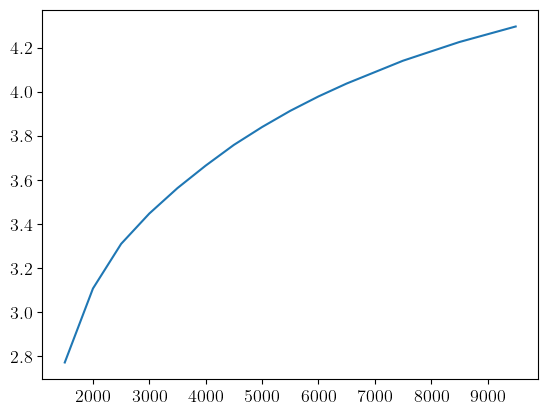

In [98]:
plt.plot(data['ells'], data['datapoints'])

In [44]:
# priors = [(df[p].to_numpy().min(), df[p].to_numpy().max()) for p in df.columns]

norms = []
for i, p in enumerate(priors):
    if i == 2:
        vmin = p[0] - np.log10(1e2)
        vmax = p[1] - np.log10(1e2)
    else:
        vmin = p[0]
        vmax = p[1]
    n = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)
        
    norms.append(n)

cmap = plt.get_cmap('viridis')

In [78]:
spectra_path = 'ps_ee'

In [6]:
from scipy.integrate import cumulative_trapezoid

def xe2tau_plot(z):
        """
        Computes redshift evolution of the model's optical depth. This one is reversed for plotting purposes

        Parameters
        ----------
            z: (array of) float(s)
                Redshift range used to compute the optical depth.
        """
        cos = cosmology.FlatLambdaCDM(
            H0=ksz.h * 100, Tcmb0=ksz.T_cmb, Ob0=ksz.Ob_0, Om0=ksz.Om_0
        )
        z = np.sort(z)
        xe = np.sort(ksz.xe(z))[::-1]

        integ = constants.c.value * constants.sigma_T.value * ksz.nh * xe \
            / cos.H(z).si.value * (1+z)**2
        tofz = cumulative_trapezoid(integ, z, initial=0)

        return tofz

In [ ]:
fig, ax = plt.subplots(sharex=True, figsize=(10,8))
fig.subplots_adjust(hspace=.00)

import matplotlib.cm as cm
import matplotlib.colors as mcolors

norm = matplotlib.colors.Normalize(vmin=df["fesc"].min(), vmax=df["fesc"].max())
cmap = plt.get_cmap('viridis')

for i, sn in enumerate(xe_histories):
    if sn not in df.index.to_list():
        continue
    if i % 1000 == 0:
        # continue
        print(f"Completed {i+1}/{len(df)}...")


    z_data = xe_histories[sn]['z']
    xe_data = xe_histories[sn]['xe']
    
    color = cmap(norm(df.loc[sn]['fesc'])) 
    # if not ((Planck - 2.0 * Planck_err) <= ksz.tau <=(Planck + 2.0 * Planck_err)):
    #     color = 'darkblue'


    ax.semilogy(z3, utils.xe(z3, z_data, xe_data), color=color, alpha=.25)
    # ax[1].plot(z3, xe2tau_plot(z3), color=color, alpha=.25)

ax.tick_params(axis='both', labelsize=30)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))

# Optional: make them visible
# ax.tick_params(axis='x', which='minor', length=4, color='red')
# sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
#   #  sm.set_array([])  # required for matplotlib < 3.2
# cbar = fig.colorbar(sm, ax=ax, orientation="horizontal", location="top", shrink=0.95, ticks=[0.05, .275, 0.5])

base_cmap = cm.get_cmap('viridis', 3)   # 3 discrete colors from viridis
colors_fesc = base_cmap(np.arange(3))        # RGBA array of 3 colors

# Make a discrete ListedColormap
cmap_fesc = mcolors.ListedColormap(colors_fesc)
bounds = [0, 1, 2, 3]
norm_fesc = mcolors.BoundaryNorm(bounds, cmap_fesc.N)

# Dummy mappable for colorbar
sm_fesc = cm.ScalarMappable(cmap=cmap_fesc, norm=norm_fesc)
sm_fesc.set_array([])

cbar_fesc = plt.colorbar(sm_fesc, orientation="horizontal", location="top", shrink=0.95, ticks=[0.5, 1.5, 2.5], ax=ax)
fesc_vals = sorted(df['fesc'].unique())
cbar_fesc.ax.set_xticklabels(fesc_vals)
cbar_fesc.set_label(astro_wunits[-3], fontsize=20)

ax.set_xlim(3.2,16)

ax.set_xlabel(rf"$z$", fontsize=30)
ax.set_ylabel(rf"$x_e(z)$", fontsize=30)

for ax in fig.axes:
    for artist in ax.get_children():
        artist.set_rasterized(True)

cbar_fesc.set_label(astro_wunits[4], fontsize=25)

fig.savefig('xe.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)

Completed 1001/6797...
Completed 3001/6797...
Completed 4001/6797...
Completed 5001/6797...
Completed 6001/6797...
Completed 8001/6797...


/tmp/ipykernel_678047/2740970624.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = cm.get_cmap('viridis', 3)   # 3 discrete colors from viridis
/tmp/ipykernel_678047/2740970624.py:62: UserWarning: Rasterization of 'Spine' will be ignored
  artist.set_rasterized(True)


In [ ]:
import numpy as np
import matplotlib.colors as mcolors

sm = matplotlib.cm.ScalarMappable(
    norm=mcolors.LogNorm(vmin=norms[2+pi].vmin, vmax=norms[2+pi].vmax), 
    cmap=cmap
)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax[pi], orientation="horizontal", location="top", shrink=0.85)

# Generate ticks in original data space
ticks = np.logspace(np.log10(norms[2+pi].vmin), np.log10(norms[2+pi].vmax), num=4)
cbar.set_ticks(ticks)

# Format labels without scientific notation
cbar.set_ticklabels([f"{t:.0f}" if t >= 1 else f"{t:.2g}" for t in ticks])

cbar.set_label(astro_wunits[2+pi], fontsize=20)


In [ ]:
from scipy.interpolate import interp1d

spectra_path = 'ps_ee'

xe_interp = np.array([.01, .5, .96]) # First I want to pick the ionisation fractions I want
# xe_interp = np.array([.01, .1, .5, .8, .96])

fig, axes = plt.subplots(xe_interp.size, 3, figsize=(20,12), sharex=True, sharey=True) # +1 for xe(z)
fig.subplots_adjust(wspace=0.0, hspace=0.0)

for i, sn in enumerate(df.index):
    if i % 1000 == 0:
        print(f'On {i}th sim')
    # if i % 1000 != 0:   
    #     continue
    sim = Cat(sn, skip_early=True,
            base_dir=base_dir,
            path_spectra=spectra_path,
            LoReLi_format=True,
            verbose=False)

    if sim.xe.max() < .97:
        print(sn)
        print(sim.xe.max())
        continue
    
    # Then I find the redshifts for these key ion fracs 
    z_xe = interp1d(sim.xe, sim.z)

    # Then I need to interpolate the Pee for these redshifts
    Pee_func = interp1d(sim.z, sim.Pee, axis=0)
    Pee = Pee_func(z_xe(xe_interp))

    for xi, xe in enumerate(xe_interp):
        ax = axes[xi]
        for pi, p in enumerate(df.loc[sn][2:]):
            if pi == 0:
                color = cmap(norms[2+pi](p - np.log10(1e2))) 
            else:
                color = cmap(norms[2+pi](p))
            ax[pi].loglog(sim.k, Pee[xi], color=color, alpha=.5)

ax = axes[0]
   
for pi, p in enumerate(df.columns[2:]):
    if pi != 2:
        sm = matplotlib.cm.ScalarMappable(norm=norms[2+pi], cmap=cmap)
        sm.set_array([])  # required for matplotlib < 3.2
        cbar = fig.colorbar(sm, ax=ax[pi], orientation="horizontal", location="top", shrink=0.85)
        # if pi == 0:
        #     ticks = np.logspace(np.log10(norms[2+pi].vmin), np.log10(norms[2+pi].vmax), num=4)
        #     cbar.set_ticks(ticks)
        #     cbar.set_ticklabels([f"{t:.2f}" if t >= 1 else f"{t:.2g}" for t in ticks])
        # else:
        cbar.ax.xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=4))
        cbar.set_label(astro_wunits[2+pi], fontsize=20)
    else:
        base_cmap = cm.get_cmap('viridis', 3)   # 3 discrete colors from viridis
        colors_fesc = base_cmap(np.arange(3))        # RGBA array of 3 colors
        
        # Make a discrete ListedColormap
        cmap_fesc = mcolors.ListedColormap(colors_fesc)
        bounds = [0, 1, 2, 3]
        norm_fesc = mcolors.BoundaryNorm(bounds, cmap_fesc.N)
        
        # Dummy mappable for colorbar
        sm_fesc = cm.ScalarMappable(cmap=cmap_fesc, norm=norm_fesc)
        sm_fesc.set_array([])
        
        cbar_fesc = plt.colorbar(sm_fesc, orientation="horizontal", location="top",
                                 shrink=0.95, ticks=[0.5, 1.5, 2.5], ax=ax[pi])
        fesc_vals = sorted(df['fesc'].unique())
        cbar_fesc.ax.set_xticklabels(fesc_vals)
        cbar_fesc.set_label(astro_wunits[2+pi], fontsize=20)

for i, xei in enumerate(xe_interp):
    axes[i,0].set_ylabel(rf"     $x_{{e}}={xei}$ \\ $P_{{ee}}(k) \, [\mathrm{{Mpc}}^{{3}}]$", fontsize=20)

# [axes[0,i].set_title(astro_pnames_formatted[i], fontsize=16) for i in range(len(df.columns))]

# #[a.set_title() for a in axes[-1]]
[a.set_xlabel(r'$k$ [$\mathrm{{Mpc}}^{-1}$]', fontsize=25) for a in axes[-1]]

for ax in fig.axes:
    for artist in ax.get_children():
        artist.set_rasterized(True)

fig.savefig('LoReLi_suite.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)

On 0th sim


On 0th sim
On 1000th sim
On 2000th sim
On 3000th sim
On 4000th sim
On 5000th sim
On 6000th sim


/tmp/ipykernel_2821083/1229027272.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = cm.get_cmap('viridis', 3)   # 3 discrete colors from viridis
/tmp/ipykernel_2821083/1229027272.py:83: UserWarning: Rasterization of 'Spine' will be ignored
  artist.set_rasterized(True)


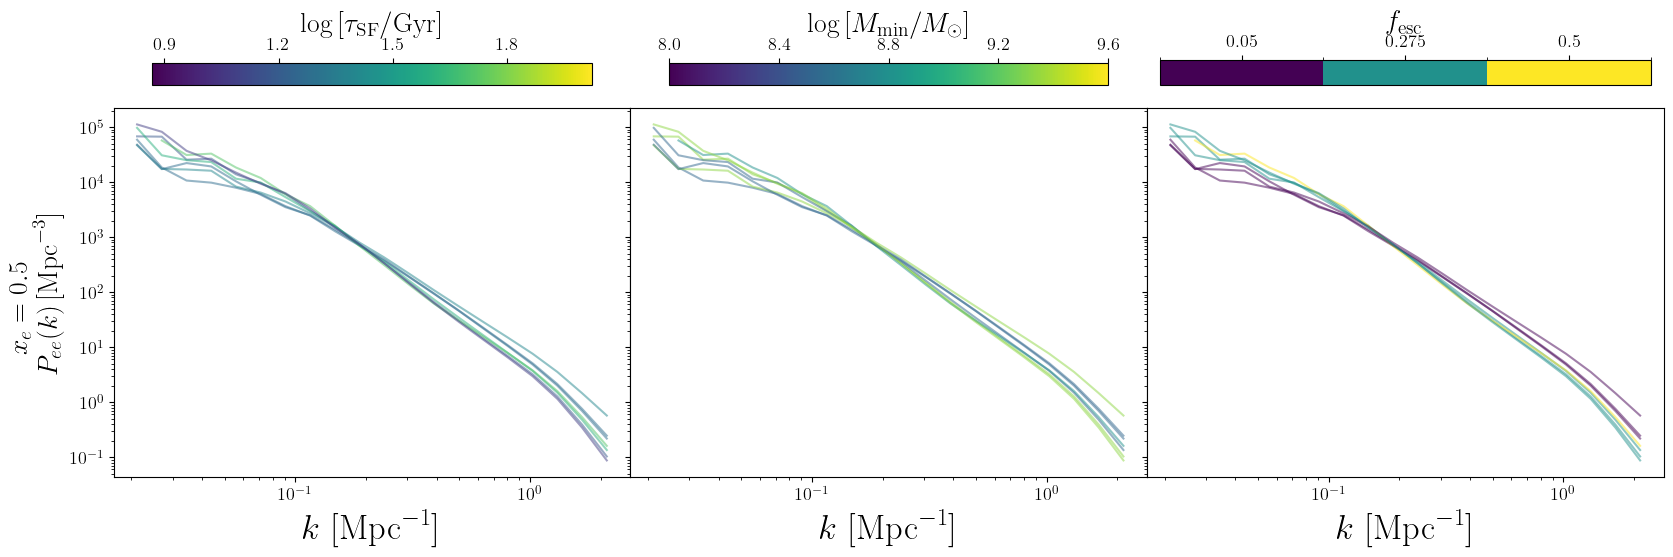

In [31]:
from scipy.interpolate import interp1d

spectra_path = 'ps_ee'

xe_interp = np.array([.5]) # np.array([.01, .5, .96]) # First I want to pick the ionisation fractions I want
# xe_interp = np.array([.01, .1, .5, .8, .96])

fig, ax = plt.subplots(xe_interp.size, 3, figsize=(20,6), sharex=True, sharey=True) # +1 for xe(z)
fig.subplots_adjust(wspace=0.0, hspace=0.0)

for i, sn in enumerate(df.index):
    if i % 1000 == 0:
        print(f'On {i}th sim')
    if i % 1000 != 0:   
        continue
    sim = Cat(sn, skip_early=True,
            base_dir=base_dir,
            path_spectra=spectra_path,
            LoReLi_format=True,
            verbose=False)

    if sim.xe.max() < .97:
        print(sn)
        print(sim.xe.max())
        continue
    
    # Then I find the redshifts for these key ion fracs 
    z_xe = interp1d(sim.xe, sim.z)

    # Then I need to interpolate the Pee for these redshifts
    Pee_func = interp1d(sim.z, sim.Pee, axis=0)
    Pee = Pee_func(z_xe(xe_interp))

    for xi, xe in enumerate(xe_interp):
        for pi, p in enumerate(df.loc[sn][2:]):
            if pi == 0:
                color = cmap(norms[2+pi](p - np.log10(1e2))) 
            else:
                color = cmap(norms[2+pi](p))
            ax[pi].loglog(sim.k, Pee[xi], color=color, alpha=.5)
   
for pi, p in enumerate(df.columns[2:]):
    if pi != 2:
        sm = matplotlib.cm.ScalarMappable(norm=norms[2+pi], cmap=cmap)
        sm.set_array([])  # required for matplotlib < 3.2
        cbar = fig.colorbar(sm, ax=ax[pi], orientation="horizontal", location="top", shrink=0.85)
        # if pi == 0:
        #     ticks = np.logspace(np.log10(norms[2+pi].vmin), np.log10(norms[2+pi].vmax), num=4)
        #     cbar.set_ticks(ticks)
        #     cbar.set_ticklabels([f"{t:.2f}" if t >= 1 else f"{t:.2g}" for t in ticks])
        # else:
        cbar.ax.xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=4))
        cbar.set_label(astro_wunits[2+pi], fontsize=20)
    else:
        base_cmap = cm.get_cmap('viridis', 3)   # 3 discrete colors from viridis
        colors_fesc = base_cmap(np.arange(3))        # RGBA array of 3 colors
        
        # Make a discrete ListedColormap
        cmap_fesc = mcolors.ListedColormap(colors_fesc)
        bounds = [0, 1, 2, 3]
        norm_fesc = mcolors.BoundaryNorm(bounds, cmap_fesc.N)
        
        # Dummy mappable for colorbar
        sm_fesc = cm.ScalarMappable(cmap=cmap_fesc, norm=norm_fesc)
        sm_fesc.set_array([])
        
        cbar_fesc = plt.colorbar(sm_fesc, orientation="horizontal", location="top",
                                 shrink=0.95, ticks=[0.5, 1.5, 2.5], ax=ax[pi])
        fesc_vals = sorted(df['fesc'].unique())
        cbar_fesc.ax.set_xticklabels(fesc_vals)
        cbar_fesc.set_label(astro_wunits[2+pi], fontsize=20)

for i, xei in enumerate(xe_interp):
    ax[0].set_ylabel(rf"     $x_{{e}}={xei}$ \\ $P_{{ee}}(k) \, [\mathrm{{Mpc}}^{{3}}]$", fontsize=20)

# [axes[0,i].set_title(astro_pnames_formatted[i], fontsize=16) for i in range(len(df.columns))]

# #[a.set_title() for a in axes[-1]]
[a.set_xlabel(r'$k$ [$\mathrm{{Mpc}}^{-1}$]', fontsize=25) for a in ax]

for a in fig.axes:
    for artist in a.get_children():
        artist.set_rasterized(True)

fig.savefig('LoReLi_suite_midpoint.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)

In [ ]:
from scipy.interpolate import interp1d

spectra_path = 'ps_ee'

xe_interp = np.array([.5]) # np.array([.01, .5, .96]) # First I want to pick the ionisation fractions I want
# xe_interp = np.array([.01, .1, .5, .8, .96])

fig, ax = plt.subplots(3, xe_interp.size, figsize=(10,15), sharex=True, sharey=True) # +1 for xe(z)
fig.subplots_adjust(wspace=0.0, hspace=0.0)

for i, sn in enumerate(df.index):
    if i % 1000 == 0:
        print(f'On {i}th sim')
    if i % 10 != 0:   
        continue
    sim = Cat(sn, skip_early=True,
            base_dir=base_dir,
            path_spectra=spectra_path,
            LoReLi_format=True,
            verbose=False)

    if sim.xe.max() < .97:
        print(sn)
        print(sim.xe.max())
        continue
    
    # Then I find the redshifts for these key ion fracs 
    z_xe = interp1d(sim.xe, sim.z)

    # Then I need to interpolate the Pee for these redshifts
    Pee_func = interp1d(sim.z, sim.Pee, axis=0)
    Pee = Pee_func(z_xe(xe_interp))

    for xi, xe in enumerate(xe_interp):
        for pi, p in enumerate(df.loc[sn][2:]):
            if pi == 0:
                color = cmap(norms[2+pi](p - np.log10(1e2))) 
            else:
                color = cmap(norms[2+pi](p))
            ax[pi].loglog(sim.k, Pee[xi], color=color, alpha=.5)
   
for pi, p in enumerate(df.columns[2:]):
    if pi != 2:
        sm = matplotlib.cm.ScalarMappable(norm=norms[2+pi], cmap=cmap)
        sm.set_array([])  # required for matplotlib < 3.2
        cbar = fig.colorbar(sm, ax=ax[pi], orientation="vertical", location="right", shrink=0.99)
        # if pi == 0:
        #     ticks = np.logspace(np.log10(norms[2+pi].vmin), np.log10(norms[2+pi].vmax), num=4)
        #     cbar.set_ticks(ticks)
        #     cbar.set_ticklabels([f"{t:.2f}" if t >= 1 else f"{t:.2g}" for t in ticks])
        # else:
        cbar.ax.yaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=4))
        cbar.set_label(astro_wunits[2+pi], fontsize=20)
    else:
        base_cmap = cm.get_cmap('viridis', 3)   # 3 discrete colors from viridis
        colors_fesc = base_cmap(np.arange(3))        # RGBA array of 3 colors
        
        # Make a discrete ListedColormap
        cmap_fesc = mcolors.ListedColormap(colors_fesc)
        bounds = [0, 1, 2, 3]
        norm_fesc = mcolors.BoundaryNorm(bounds, cmap_fesc.N)
        
        # Dummy mappable for colorbar
        sm_fesc = cm.ScalarMappable(cmap=cmap_fesc, norm=norm_fesc)
        sm_fesc.set_array([])
        
        cbar_fesc = plt.colorbar(sm_fesc, orientation="vertical", location="right",
                                 shrink=0.99, ticks=[0.5, 1.5, 2.5], ax=ax[pi])
        fesc_vals = sorted(df['fesc'].unique())
        cbar_fesc.ax.set_yticklabels(fesc_vals)
        cbar_fesc.set_label(astro_wunits[2+pi], fontsize=20)

[ax[i].set_ylabel(rf"$P_{{ee}}(k) \, [\mathrm{{Mpc}}^{{3}}]$", fontsize=20) for i in range(3)]

# [axes[0,i].set_title(astro_pnames_formatted[i], fontsize=16) for i in range(len(df.columns))]

# #[a.set_title() for a in axes[-1]]
[a.set_xlabel(r'$k$ [$\mathrm{{Mpc}}^{-1}$]', fontsize=30) for a in ax]

for a in fig.axes:
    for artist in a.get_children():
        artist.set_rasterized(True)

fig.savefig('LoReLi_suite_midpoint.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)

On 0th sim


In [ ]:
fig, ax = plt.subplots(3, 1, sharex=True, sharey=True, figsize=(12,20))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

ax = ax.flatten()

from matplotlib.ticker import AutoMinorLocator, MultipleLocator, MaxNLocator

from scipy.interpolate import interp1d

spectra_path = 'ps_ee'

xe_interp = np.array([.5]) #np.array([.01, .5, .96]) # First I want to pick the ionisation fractions I want
# xe_interp = np.array([.01, .1, .5, .8, .96])

fig, axes = plt.subplots(xe_interp.size, 3, figsize=(20,12), sharex=True, sharey=True) # +1 for xe(z)
fig.subplots_adjust(wspace=0.0, hspace=0.0)

for i, sn in enumerate(df.index):
    if i % 1000 == 0:
        print(f'On {i}th sim')
    # if i % 1000 != 0:   
    #     continue
    sim = Cat(sn, skip_early=True,
            base_dir=base_dir,
            path_spectra=spectra_path,
            LoReLi_format=True,
            verbose=False)

    if sim.xe.max() < .97:
        print(sn)
        print(sim.xe.max())
        continue
    
    # Then I find the redshifts for these key ion fracs 
    z_xe = interp1d(sim.xe, sim.z)

    # Then I need to interpolate the Pee for these redshifts
    Pee_func = interp1d(sim.z, sim.Pee, axis=0)
    Pee = Pee_func(z_xe(xe_interp))

    for xi, xe in enumerate(xe_interp):
        ax = axes[xi]
        for pi, p in enumerate(df.loc[sn][2:]):
            if pi == 0:
                color = cmap(norms[2+pi](p - np.log10(1e2))) 
            else:
                color = cmap(norms[2+pi](p))
            ax[pi].loglog(sim.k, Pee[xi], color=color, alpha=.5)

    # ax[i].set_title(astro_pnames_formatted[i], fontsize=16)
ax[i].set_xlabel(rf"$\ell$", fontsize=30)

ax[i].xaxis.set_major_locator(MaxNLocator(nbins=6))
ax[i].xaxis.set_minor_locator(AutoMinorLocator(2))  # 2 minor ticks between majors
ax[i].tick_params(axis='x', which='minor', length=4, labelsize=25)
ax[i].tick_params(axis='both', which='major', labelsize=20)

[a.set_ylabel(r'$D_\ell \left[\mathrm{\mu K^2} \right]$', fontsize=30) for a in ax]

for pi, p in enumerate(df.columns[2:]):
    if pi != 2:
        sm = matplotlib.cm.ScalarMappable(norm=norms[2+pi], cmap=cmap)
        sm.set_array([])  # required for matplotlib < 3.2
        cbar = fig.colorbar(sm, ax=ax[pi], orientation="vertical", location="right", shrink=0.85)
        if pi == 0:
            ticks = np.logspace(np.log10(norms[2+pi].vmin), np.log10(norms[2+pi].vmax), num=4)
            cbar.set_ticks(ticks)
            cbar.set_ticklabels([f"{t:.2f}" if t >= 1 else f"{t:.2g}" for t in ticks])
        else:
            cbar.ax.yaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=4))
        cbar.set_label(astro_wunits[2+pi], fontsize=20)
    else:
        base_cmap = cm.get_cmap('viridis', 3)   # 3 discrete colors from viridis
        colors_fesc = base_cmap(np.arange(3))        # RGBA array of 3 colors
        
        # Make a discrete ListedColormap
        cmap_fesc = mcolors.ListedColormap(colors_fesc)
        bounds = [0, 1, 2, 3]
        norm_fesc = mcolors.BoundaryNorm(bounds, cmap_fesc.N)
        
        # Dummy mappable for colorbar
        sm_fesc = cm.ScalarMappable(cmap=cmap_fesc, norm=norm_fesc)
        sm_fesc.set_array([])
        
        cbar_fesc = plt.colorbar(sm_fesc, orientation="vertical", location="right",
                                 shrink=0.99, ticks=[0.5, 1.5, 2.5], ax=ax[pi])
        fesc_vals = sorted(df['fesc'].unique())
        cbar_fesc.ax.set_yticklabels(fesc_vals)
        cbar_fesc.set_label(astro_wunits[2+pi], fontsize=30)

# Add minor ticks to x-axis
for ax in fig.axes:
    for artist in ax.get_children():
        artist.set_rasterized(True)

#fig.savefig('kSZ_spectra.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)

On 0th sim
On 1000th sim
On 2000th sim
13925
0.87817
On 3000th sim
On 4000th sim
On 5000th sim
On 6000th sim


/var/folders/8t/k878xr_j2fqgy_993tg3qy7c0000gn/T/ipykernel_2024/3016379786.py:61: UserWarning: Rasterization of 'Spine' will be ignored
  artist.set_rasterized(True)


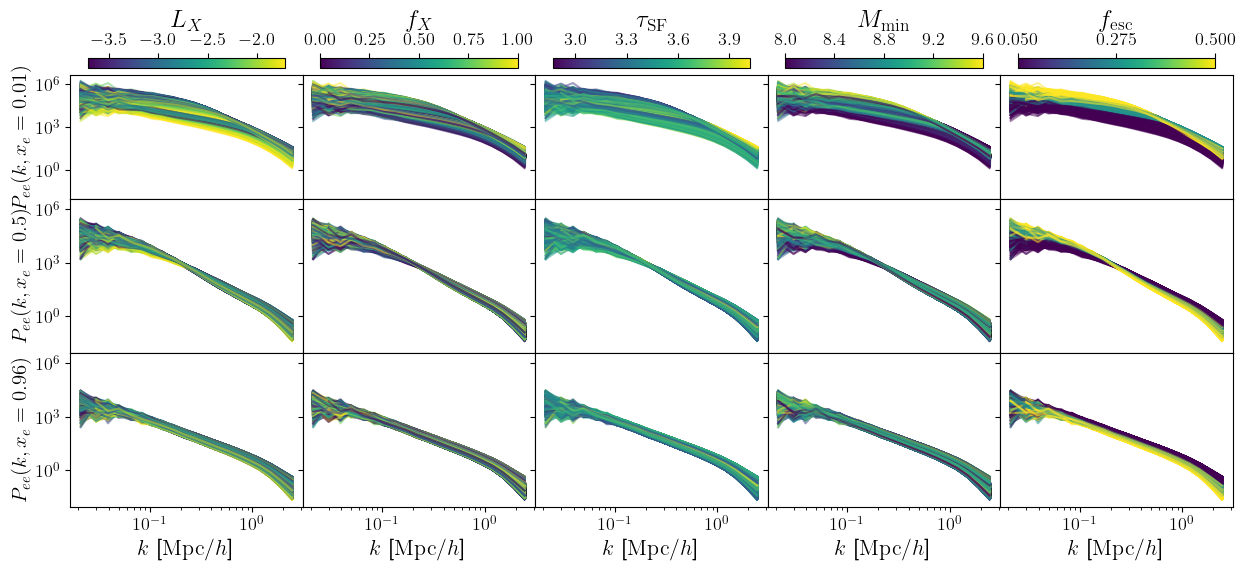

In [21]:
from scipy.interpolate import interp1d

xe_interp = np.array([.01, .5, .96]) # First I want to pick the ionisation fractions I want
# xe_interp = np.array([.01, .1, .5, .8, .96])

fig, axes = plt.subplots(xe_interp.size, 5, figsize=(15,6), sharex=True, sharey=True) # +1 for xe(z)
fig.subplots_adjust(wspace=0.0, hspace=0.0)

for i, sn in enumerate(df.index):
    if i % 1000 == 0:
        print(f'On {i}th sim')
        # continue
    sim = Cat(sn, skip_early=True,
            base_dir=base_dir,
            path_spectra=spectra_path,
            LoReLi_format=True,
            verbose=False)

    if sim.xe.max() < .97:
        print(sn)
        print(sim.xe.max())
        continue
    
    # Then I find the redshifts for these key ion fracs 
    z_xe = interp1d(sim.xe, sim.z)

    # Then I need to interpolate the Pee for these redshifts
    Pee_func = interp1d(sim.z, sim.Pee, axis=0)
    Pee = Pee_func(z_xe(xe_interp))

    for xi, xe in enumerate(xe_interp):
        ax = axes[xi]
        for pi, p in enumerate(df.loc[sn]):
            color = cmap(norms[pi](p))
            ax[pi].loglog(sim.k, Pee[xi], color=color, alpha=.5)

ax = axes[0]
for pi, p in enumerate(df.columns):

    sm = matplotlib.cm.ScalarMappable(norm=norms[pi], cmap=cmap)
    sm.set_array([])  # required for matplotlib < 3.2

    if pi != 4:
        cbar = fig.colorbar(sm, ax=ax[pi], orientation="horizontal", location="top", shrink=0.85)
        cbar.ax.xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=4))
    if pi == 4:
        cbar = fig.colorbar(sm, ax=ax[pi], orientation="horizontal", location="top", shrink=0.85, ticks=[0.05, .275, 0.5])

    cbar.set_label(astro_pnames_formatted[pi], fontsize=18)

for i, xei in enumerate(xe_interp):
    axes[i,0].set_ylabel(rf"$P_{{ee}}(k, x_{{e}}={xei})$", fontsize=15)

# [axes[0,i].set_title(astro_pnames_formatted[i], fontsize=16) for i in range(len(df.columns))]

# #[a.set_title() for a in axes[-1]]
[a.set_xlabel(r'$k$ [$\mathrm{{Mpc}}$/$h$]', fontsize=16) for a in axes[-1]]

for ax in fig.axes:
    for artist in ax.get_children():
        artist.set_rasterized(True)

fig.savefig('LoReLi_suite_withXrays.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)

In [16]:
from scipy.interpolate import interp1d

xe_interp = np.array([.01, .5, .96]) # First I want to pick the ionisation fractions I want
# xe_interp = np.array([.01, .1, .5, .8, .96])

fig, axes = plt.subplots(xe_interp.size, 5, figsize=(15,6), sharex=True, sharey=True) # +1 for xe(z)
fig.subplots_adjust(wspace=0.0, hspace=0.0)

for i, sn in enumerate(df.index):
    if i % 1000 == 0:
        print(f'On {i}th sim')
        # continue
    sim = Cat(sn, skip_early=True,
            base_dir=base_dir,
            path_spectra=spectra_path,
            LoReLi_format=True,
            verbose=False)

    if sim.xe.max() < .97:
        print(sn)
        print(sim.xe.max())
        continue
    
    # Then I find the redshifts for these key ion fracs 
    z_xe = interp1d(sim.xe, sim.z)

    # Then I need to interpolate the Pee for these redshifts
    Pee_func = interp1d(sim.z, sim.Pee, axis=0)
    Pee = Pee_func(z_xe(xe_interp))

    for xi, xe in enumerate(xe_interp):
        ax = axes[xi]
        for pi, p in enumerate(df.loc[sn]):
            color = cmap(norms[pi](p))
            ax[pi].loglog(sim.k, Pee[xi], color=color, alpha=.5)

ax = axes[0]
for pi, p in enumerate(df.columns):

    sm = matplotlib.cm.ScalarMappable(norm=norms[pi], cmap=cmap)
    sm.set_array([])  # required for matplotlib < 3.2

    if pi != 4:
        cbar = fig.colorbar(sm, ax=ax[pi], orientation="horizontal", location="top", shrink=0.85)
        cbar.ax.xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=4))
    if pi == 4:
        cbar = fig.colorbar(sm, ax=ax[pi], orientation="horizontal", location="top", shrink=0.85, ticks=[0.05, .275, 0.5])

    cbar.set_label(astro_pnames_formatted[pi], fontsize=18)

for i, xei in enumerate(xe_interp):
    axes[i,0].set_ylabel(rf"$P_{{ee}}(k, x_{{e}}={xei})$", fontsize=15)

# [axes[0,i].set_title(astro_pnames_formatted[i], fontsize=16) for i in range(len(df.columns))]

# #[a.set_title() for a in axes[-1]]
[a.set_xlabel(r'$k$ [$\mathrm{{Mpc}}$/$h$]', fontsize=16) for a in axes[-1]]

for ax in fig.axes:
    for artist in ax.get_children():
        artist.set_rasterized(True)

fig.savefig('LoReLi_suite_withXrays.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)

(array([3.18673038, 3.48725153, 3.60112525, 3.69738629, 3.0728746 ,
        3.08461202, 3.28887495, 3.49312331, 3.8053853 , 3.50486488,
        3.18087105, 3.17498965, 3.49899936, 3.39686162, 3.07874673,
        3.40274271, 3.38512346, 3.81125319, 3.70912574, 3.61286859,
        3.60699368, 3.71499997, 3.37925111, 4.02138365, 3.30061722,
        3.51074603, 2.86858567, 3.1926232 , 3.29473069, 3.39100572,
        3.58937984, 3.27712767, 3.91338464, 3.59525365, 2.9707187 ,
        3.40861303, 3.48138529, 3.28300708, 3.81712887, 3.91925596,
        3.70325698, 2.97662505]),
 array([2.86858567, 3.27712767, 3.40861303, 3.60699368, 3.91925596]))

KeyboardInterrupt: 

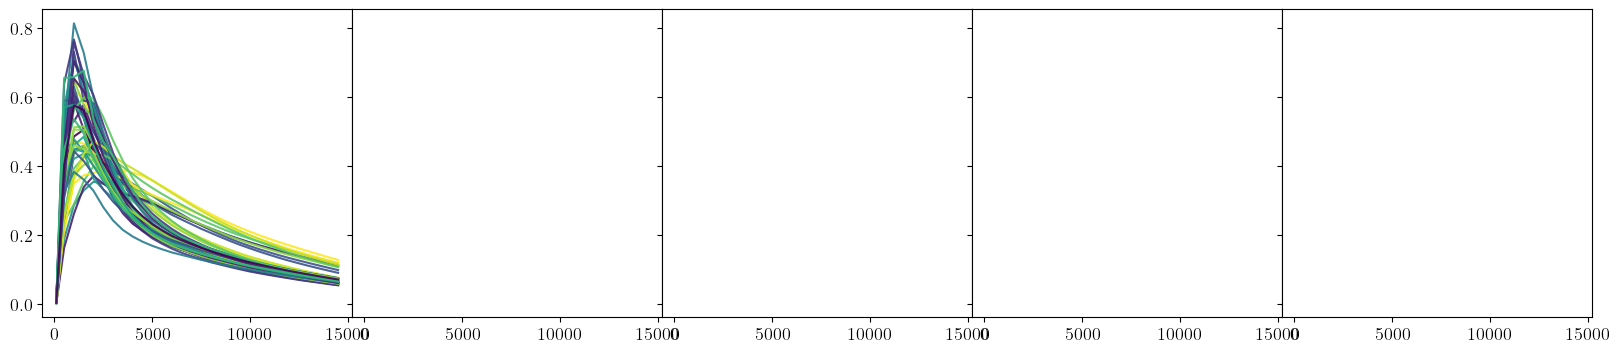

In [15]:
fig, ax = plt.subplots(1,5, sharex=True, sharey=True, figsize=(20,4))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

from matplotlib.ticker import AutoMinorLocator, MultipleLocator, MaxNLocator

# baddies = []
# failed_reion = []
for i, pname in enumerate(df.columns):
    vmin = df[pname].min()
    vmax = df[pname].max()

    norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.get_cmap('viridis')

    for j, sn in enumerate(df.index.to_list()):
        spectrum = utils.spectra(sn)

        pval = df.loc[sn][pname]
        if pname == 'tau':
            if pval not in np.sort(df['tau'].unique())[::10]:
                continue
        ax[i].plot(ells, spectrum, color=cmap(norm(pval)), alpha=.9)
    
        # if np.isclose(df.loc[sn][pname], unique).any():
        #     label = f"Value: {df.loc[sn][pname]:.5f}"
        #     legend_handles.append(plt.Line2D([0], [0], color=cmap(norm(df.loc[sn][pname])), label=label))
  #  ax[i].axhline(.5, color='gray')
    # ax[i].legend(handles=legend_handles, title="Legend")
    print(astro_pnames_formatted[i])
    # ax[i].set_title(astro_pnames_formatted[i], fontsize=16)
    ax[i].set_xlabel(rf"$\ell$", fontsize=18)

    ax[i].xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax[i].xaxis.set_minor_locator(AutoMinorLocator(2))  # 2 minor ticks between majors
    ax[i].tick_params(axis='x', which='minor', length=4, labelsize=10)

ax[0].set_ylabel(r'$D_\ell \left[\mathrm{\mu K^2} \right]$', fontsize=18)

for pi, p in enumerate(df.columns):

    sm = matplotlib.cm.ScalarMappable(norm=norms[pi], cmap=cmap)
    sm.set_array([])  # required for matplotlib < 3.2

    if pi != 4:
        cbar = fig.colorbar(sm, ax=ax[pi], orientation="horizontal", location="top", shrink=0.85)
        cbar.ax.xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=4))
    if pi == 4:
        cbar = fig.colorbar(sm, ax=ax[pi], orientation="horizontal", location="top", shrink=0.85, ticks=[0.05, .275, 0.5])

    cbar.set_label(astro_pnames_formatted[pi], fontsize=18)

# Add minor ticks to x-axis
for ax in fig.axes:
    for artist in ax.get_children():
        artist.set_rasterized(True)

#fig.savefig('kSZ_spectra.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)

In [16]:
df.index.size * .1

679.7

(0.0, 3600.0)

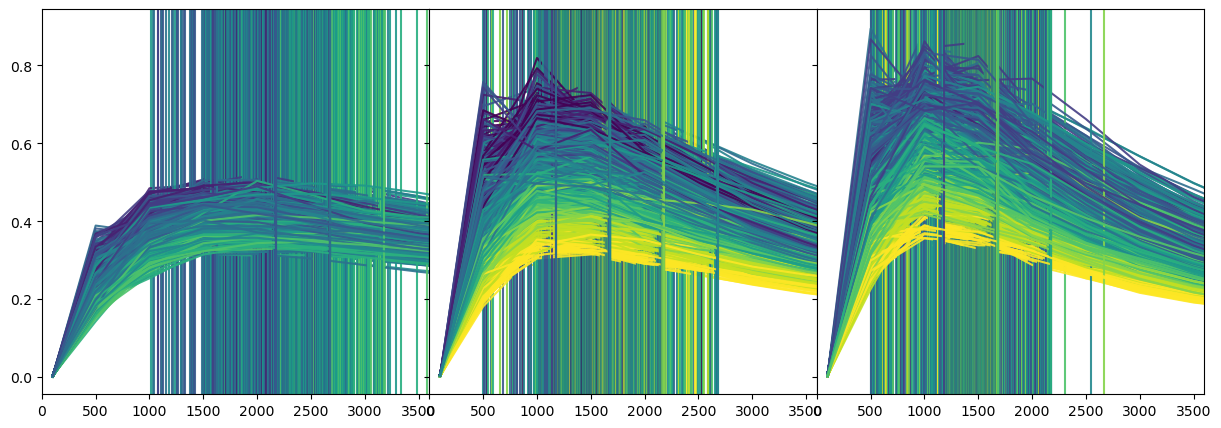

In [34]:
fig, ax = plt.subplots(2,3, sharex=True, sharey=True, figsize=(15,5))
fig.subplots_adjust(wspace=0.0)

for j, sn in enumerate(df.index.to_list()):
    spectrum = utils.spectra(sn)

    idx = np.where(np.sort(df['fesc'].unique()) == df.loc[sn]['fesc'])[0]

    vmin = df['tau'].min()
    vmax = df['tau'].max()

    norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.get_cmap('viridis')
    
    pval = df.loc[sn]['tau']
    ax[*idx].plot(ells, spectrum, color=cmap(norm(pval)), alpha=.9)
    ax[*idx].axvline(ells[np.argmax(spectrum)] + .1 * j, color=cmap(norm(pval)), alpha=.9)

ax[0].set_xlim(0,3600)

$\tau_{\mathrm{SF}}$
$\log{M_{\mathrm{min}}}$
$f_{\mathrm{esc}}$


/tmp/ipykernel_2821083/775182362.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = cm.get_cmap('viridis', 3)   # 3 discrete colors from viridis
/tmp/ipykernel_2821083/775182362.py:76: UserWarning: Rasterization of 'Spine' will be ignored
  artist.set_rasterized(True)


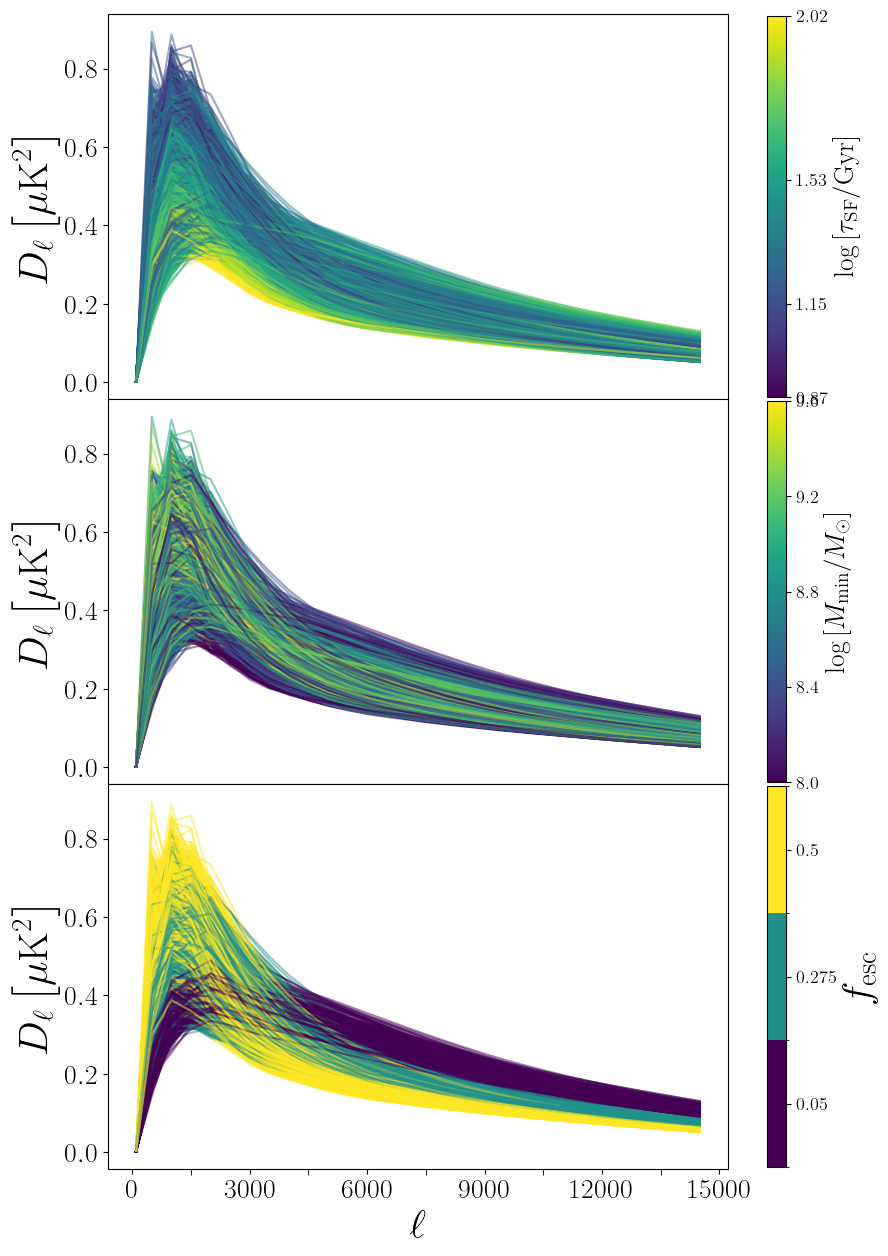

In [101]:
fig, ax = plt.subplots(3, 1, sharex=True, sharey=True, figsize=(10,15))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

ax = ax.flatten()

from matplotlib.ticker import AutoMinorLocator, MultipleLocator, MaxNLocator

# baddies = []
# failed_reion = []
for i, pname in enumerate(df.columns[2:]):
    vmin = df[pname].min()
    vmax = df[pname].max()

    norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.get_cmap('viridis')

    for j, sn in enumerate(df.index.to_list()):
        if j % 2 == 0:
            continue
        spectrum = utils.spectra(sn)

        pval = df.loc[sn][pname]
        
        ax[i].plot(ells, spectrum, color=cmap(norm(pval)), alpha=.5)
    
        # if np.isclose(df.loc[sn][pname], unique).any():
        #     label = f"Value: {df.loc[sn][pname]:.5f}"
        #     legend_handles.append(plt.Line2D([0], [0], color=cmap(norm(df.loc[sn][pname])), label=label))
  #  ax[i].axhline(.5, color='gray')
    # ax[i].legend(handles=legend_handles, title="Legend")
    print(astro_pnames_formatted[2+i])
    # ax[i].set_title(astro_pnames_formatted[i], fontsize=16)
    ax[i].set_xlabel(rf"$\ell$", fontsize=30)

    ax[i].xaxis.set_major_locator(MaxNLocator(nbins=6))
    ax[i].xaxis.set_minor_locator(AutoMinorLocator(2))  # 2 minor ticks between majors
    ax[i].tick_params(axis='x', which='minor', length=4, labelsize=25)
    ax[i].tick_params(axis='both', which='major', labelsize=20)

[a.set_ylabel(r'$D_\ell \left[\mathrm{\mu K^2} \right]$', fontsize=30) for a in ax]

for pi, p in enumerate(df.columns[2:]):
    if pi != 2:
        sm = matplotlib.cm.ScalarMappable(norm=norms[2+pi], cmap=cmap)
        sm.set_array([])  # required for matplotlib < 3.2
        cbar = fig.colorbar(sm, ax=ax[pi], orientation="vertical", location="right", shrink=0.99)
        if pi == 0:
            ticks = np.logspace(np.log10(norms[2+pi].vmin), np.log10(norms[2+pi].vmax), num=4)
            cbar.set_ticks(ticks)
            cbar.set_ticklabels([f"{t:.2f}" if t >= 1 else f"{t:.2g}" for t in ticks])
        else:
            cbar.ax.yaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=4))
        cbar.set_label(astro_wunits[2+pi], fontsize=20)
    else:
        base_cmap = cm.get_cmap('viridis', 3)   # 3 discrete colors from viridis
        colors_fesc = base_cmap(np.arange(3))        # RGBA array of 3 colors
        
        # Make a discrete ListedColormap
        cmap_fesc = mcolors.ListedColormap(colors_fesc)
        bounds = [0, 1, 2, 3]
        norm_fesc = mcolors.BoundaryNorm(bounds, cmap_fesc.N)
        
        # Dummy mappable for colorbar
        sm_fesc = cm.ScalarMappable(cmap=cmap_fesc, norm=norm_fesc)
        sm_fesc.set_array([])
        
        cbar_fesc = plt.colorbar(sm_fesc, orientation="vertical", location="right",
                                 shrink=0.99, ticks=[0.5, 1.5, 2.5], ax=ax[pi])
        fesc_vals = sorted(df['fesc'].unique())
        cbar_fesc.ax.set_yticklabels(fesc_vals)
        cbar_fesc.set_label(astro_wunits[2+pi], fontsize=30)

# Add minor ticks to x-axis
for ax in fig.axes:
    for artist in ax.get_children():
        artist.set_rasterized(True)

fig.savefig('kSZ_spectra.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)

In [66]:
df.columns

Index(['fX', 'rHS', 'tau', 'Mmin', 'fesc'], dtype='object')

In [73]:
unique = df[['tau','Mmin','fesc']].drop_duplicates().shape[0]
unique

112

In [60]:
for p in df.columns:
    print(len(df[p].value_counts().to_numpy()))

13
6
42
7
3


$\log{L_X}$
$r_{\mathrm{H/S}}$
$\tau_{\mathrm{SF}}$
$\log{M_{\mathrm{min}}}$
$f_{\mathrm{esc}}$


/var/folders/8t/k878xr_j2fqgy_993tg3qy7c0000gn/T/ipykernel_48858/406234126.py:56: UserWarning: Rasterization of 'Spine' will be ignored
  artist.set_rasterized(True)


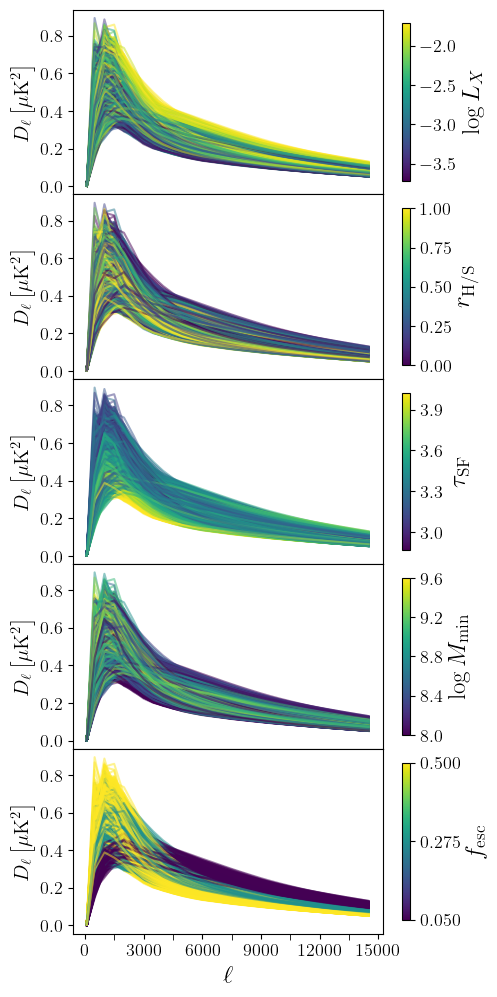

In [34]:
fig, ax = plt.subplots(5, 1, sharex=True, sharey=True, figsize=(5,12))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

ax = ax.flatten()

from matplotlib.ticker import AutoMinorLocator, MultipleLocator, MaxNLocator

# baddies = []
# failed_reion = []
for i, pname in enumerate(df.columns):
    vmin = df[pname].min()
    vmax = df[pname].max()

    norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.get_cmap('viridis')

    for j, sn in enumerate(df.index.to_list()):
        if j % 2 == 0:
            continue
        spectrum = utils.spectra(sn)

        pval = df.loc[sn][pname]
        ax[i].plot(ells, spectrum, color=cmap(norm(pval)), alpha=.5)
    
        # if np.isclose(df.loc[sn][pname], unique).any():
        #     label = f"Value: {df.loc[sn][pname]:.5f}"
        #     legend_handles.append(plt.Line2D([0], [0], color=cmap(norm(df.loc[sn][pname])), label=label))
  #  ax[i].axhline(.5, color='gray')
    # ax[i].legend(handles=legend_handles, title="Legend")
    print(astro_pnames_formatted[i])
    # ax[i].set_title(astro_pnames_formatted[i], fontsize=16)
    ax[i].set_xlabel(rf"$\ell$", fontsize=18)

    ax[i].xaxis.set_major_locator(MaxNLocator(nbins=6))
    ax[i].xaxis.set_minor_locator(AutoMinorLocator(2))  # 2 minor ticks between majors
    ax[i].tick_params(axis='x', which='minor', length=4, labelsize=10)

[a.set_ylabel(r'$D_\ell \left[\mathrm{\mu K^2} \right]$', fontsize=15) for a in ax]

for pi, p in enumerate(df.columns):

    sm = matplotlib.cm.ScalarMappable(norm=norms[pi], cmap=cmap)
    sm.set_array([])  # required for matplotlib < 3.2

    if pi != 4:
        cbar = fig.colorbar(sm, ax=ax[pi], orientation="vertical", location="right", shrink=0.85)
        cbar.ax.yaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=4))
    if pi == 4:
        cbar = fig.colorbar(sm, ax=ax[pi], orientation="vertical", location="right", shrink=0.85, ticks=[0.05, .275, 0.5])

    cbar.set_label(astro_pnames_formatted[pi], fontsize=18)

# Add minor ticks to x-axis
for ax in fig.axes:
    for artist in ax.get_children():
        artist.set_rasterized(True)

fig.savefig('kSZ_spectra_withXrays.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)

### Fiducial simulation

In [ ]:
fig, ax = plt.subplots(2,5, sharex=True, sharey=True, figsize=(12,5))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

emu_paths = ['setrandomseed3/emuv5.1', 'reduced_dataset2/emuv5.0']
xfesc = np.linspace(*priors[4], 12)

N = len(xfesc)
cmap = matplotlib.cm.get_cmap('viridis')

# Generate N evenly spaced values in [0, 1]
colors = [cmap(i / (N - 1)) for i in range(N)]
for i, path in enumerate(emu_paths):
    for n in range(5):
        emu = summon_emu(f"{path}_run{n}", verbose=True)
        tspec = emulator.kemu(true_params, **emu)
        for it, t in enumerate(xfesc):
            params = cp.deepcopy(true_params)
            params[4] = t
            espec = emulator.kemu(params, **emu)

            label = ''
            if (i == 0) and (n==0):
                label = f"fesc={t:.3f}"
            ax[i,n].plot(ells[indices], tspec - espec, color=colors[it], label=label)

            ax[1,n].set_xlabel('ells')
            ax[0,0].set_ylabel('v5.1 style')
            ax[1,0].set_ylabel('v5.0 style')

fig.legend()


In [139]:
params = df.loc[config.sn].to_numpy()
truths = dict(zip(df.columns, params))

print(f"fitting simu{config.sn} with params:")
print(params)

fiducial = alfred.utils.spectra(config.sn)

fitting simu12958 with params:
[-1.71669877  0.          3.27712767  8.53        0.275     ]


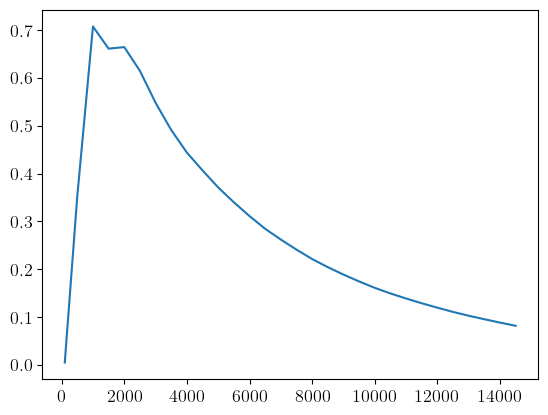

In [135]:
plt.plot(ells, fiducial)

### Surveys

We also need to assume some experimental noise configurations in order to generate our mock data. Here we plot the noise levels for each assumed survey setup.

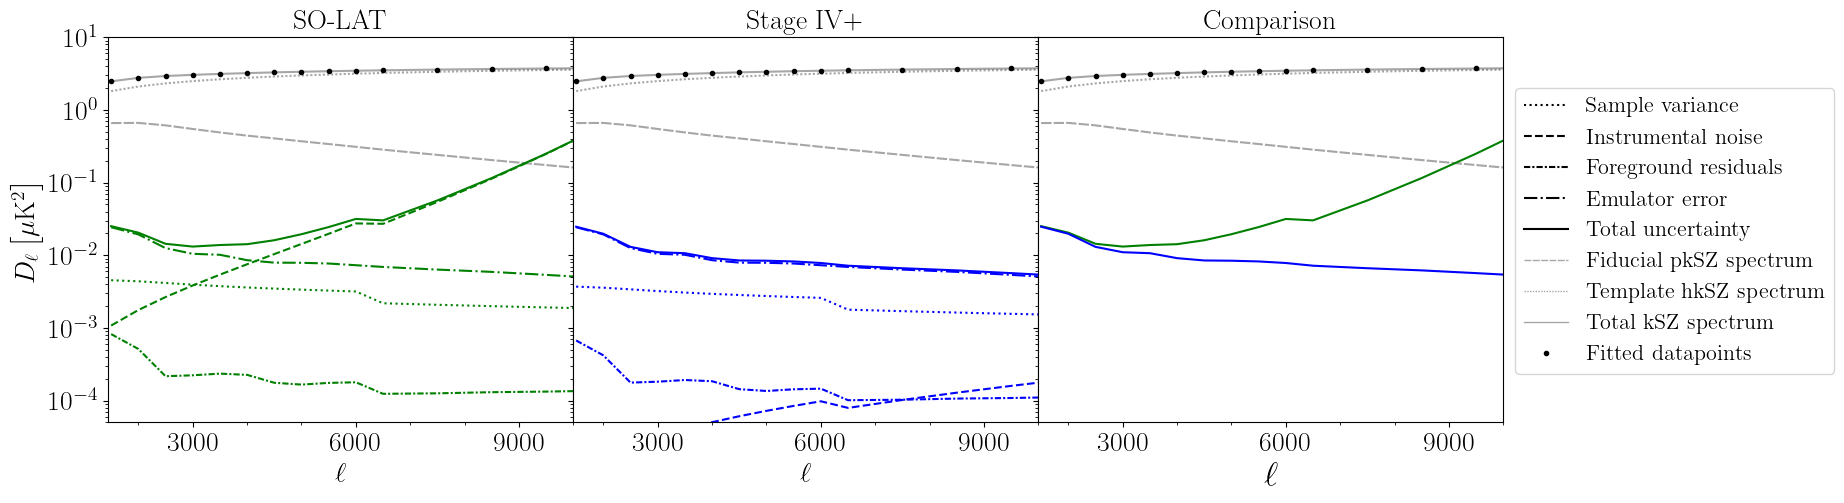

In [37]:
fig, ax = plt.subplots(1,3, sharex=True, sharey=True, figsize=(18,5))
fig.subplots_adjust(wspace=0.0)

from matplotlib.ticker import LinearLocator, MultipleLocator

from matplotlib.lines import Line2D

from alfred.parameters import colors

legend_lines = [
    Line2D([0], [0], color='black', linestyle=':', alpha=1.0, label='Sample variance'),
    Line2D([0], [0], color='black', linestyle='--', alpha=1.0, label='Instrumental noise'),
    Line2D([0], [0], color='black', linestyle=(0, (3, 1, 1, 1)), alpha=1.0, label='Foreground residuals'),
    Line2D([0], [0], color='black', linestyle='dashdot', alpha=1.0, label='Emulator error'),
    Line2D([0], [0], color='black', linestyle='-', alpha=1.0, label='Total uncertainty'),
    Line2D([0], [0], color='black', linestyle=(0, (5, 1)), alpha=.35, linewidth=1.0, label=f'Fiducial pkSZ spectrum'),
    Line2D([0], [0], color='black', linestyle=(0, (1, 1)), alpha=.35, linewidth=1.0, label=f'Template hkSZ spectrum'),
    Line2D([0], [0], color='black', linestyle='-', alpha=.35, linewidth=1.0, label=f'Total kSZ spectrum'),
    Line2D([0], [0], color='black', linestyle='', marker='.', alpha=1.0, linewidth=1.0, label=f'Fitted datapoints')  # alpha > 1 will be clipped to 1
]

data = np.load(f"{base_dir}/inference/productionruns6_addhksz/CMB-HD/noiseless/data.npz")
hksz = np.genfromtxt(f"{base_dir}/metadata/dl_ksz_hom_AG.dat").T
hksz = np.interp(ells[indices], hksz[0], hksz[1])

fiducial = utils.spectra(config.sn)[indices] + 2.5 * hksz

ax[2].plot(ells[indices], fiducial, color='black', alpha=.35)
ax[2].plot(ells[indices], fiducial, color='black', marker='.', ls='')

ax[2].plot(ells[indices], utils.spectra(config.sn)[indices], color='black', alpha=.35, ls=(0, (5, 1)))
ax[2].plot(ells[indices], 2.5 * hksz, color='black', alpha=.35, ls=(0, (1, 1)))

for i, tele in enumerate(['SO-LAT', 'CMB-HD']):
    if tele == 'CMB-HD':
        label = 'Stage IV+'
    else:
        label = tele

    ax[i].plot(ells[indices], fiducial, color='black', alpha=.35)
    ax[i].plot(ells[indices], fiducial, color='black', marker='.', ls='')

    ax[i].plot(ells[indices], utils.spectra(config.sn)[indices], color='black', alpha=.35, ls=(0, (5, 1)))
    ax[i].plot(ells[indices], 2.5 * hksz, color='black', alpha=.35, ls=(0, (1, 1)))

    cov = alfred.surveys.error_cov(ells[indices], fiducial, alfred.surveys.telescopes[tele],
                                   include_samplevar=True)
    err = np.sqrt(np.diag(cov))
    ax[i].plot(ells[indices], err, color=colors[i], ls=':')

    # Instrumental noise
    cov = alfred.surveys.error_cov(ells[indices], fiducial, alfred.surveys.telescopes[tele],
                                   include_noise=True)
    err = np.sqrt(np.diag(cov))
    ax[i].plot(ells[indices], err, #label='noise' if i == 2 else None,
                color=colors[i], ls='--')

    cov = alfred.surveys.error_cov(ells[indices], fiducial, alfred.surveys.telescopes[tele],
                                   include_emulator=True,)
    err = np.sqrt(np.diag(cov))
    ax[i].plot(ells[indices], err, #label='sample variance' if i == 2 else None,
                color=colors[i], ls='dashdot')

    # Foreground residuals
    cov = alfred.surveys.error_cov(ells[indices], fiducial, alfred.surveys.telescopes[tele],
                                   include_fgresiduals=True)
    err = np.sqrt(np.diag(cov))
    ax[i].plot(ells[indices], err, #label='sample variance' if i == 2 else None,
                color=colors[i], ls=(0, (3, 1, 1, 1)))

    # Total uncertainty
    cov = alfred.surveys.error_cov(ells[indices], fiducial, alfred.surveys.telescopes[tele],
                                   include_emulator=True, include_noise=True, include_samplevar=True, include_fgresiduals=True)
    err = np.sqrt(np.diag(cov))
    ax[i].plot(ells[indices], err, #label='emulator error' if i == 2 else None,
                color=colors[i])
    
    ax[i].set_title(f'{label}', fontsize=20)
    ax[i].set_xlabel(rf"$\ell$", fontsize=20)

    ax[2].plot(ells[indices], err, color=colors[i])

ax[2].plot([],[])

ax[2].set_title(f'Comparison', fontsize=20)
ax[2].set_xlabel(rf"$\ell$", fontsize=25)

ax[0].set_xlim(1450, 10000)
#ax[0].set_ylabel(r'$\ell(\ell+1)C_\ell^{kSZ}/2\pi$')
ax[0].set_ylabel(r'$D_\ell \left[\mathrm{\mu K^2} \right]$', fontsize=20)
ax[0].set_ylim(5e-5,10)
#ax[0].set_xscale('log')
ax[0].set_yscale('log')

[a.tick_params(axis='both', labelsize=20) for a in ax]

ax[0].xaxis.set_major_locator(MultipleLocator(3000))
ax[0].xaxis.set_minor_locator(MultipleLocator(1000))
fig.legend(handles=legend_lines, loc='upper right', fontsize=16, bbox_to_anchor=(1.09, .8))

fig.savefig('surveys_comp.png', bbox_inches='tight', pad_inches=0.05, dpi=300)


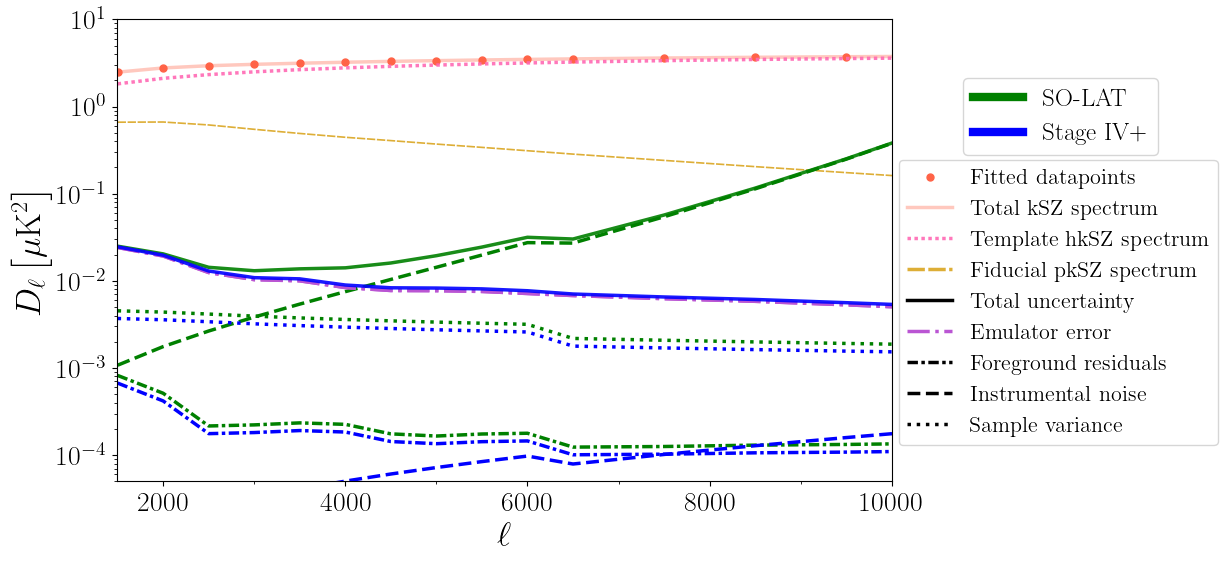

In [79]:
fig, ax = plt.subplots(1,1, figsize=(10,6))
fig.subplots_adjust(wspace=0.0)

from matplotlib.ticker import LinearLocator, MultipleLocator

from matplotlib.lines import Line2D

from alfred.parameters import colors

lw = 2.5

legend_lines = [
    Line2D([0], [0], color='black', linestyle=':', alpha=1.0, lw=lw, label='Sample variance'),
    Line2D([0], [0], color='black', linestyle='--', alpha=1.0, lw=lw, label='Instrumental noise'),
    Line2D([0], [0], color='black', linestyle=(0, (3, 1, 1, 1)), lw=lw, alpha=1.0, label='Foreground residuals'),
    Line2D([0], [0], color='mediumorchid', linestyle='dashdot', lw=lw, alpha=1.0, label='Emulator error'),
    Line2D([0], [0], color='black', linestyle='-', alpha=1.0, lw=lw, label='Total uncertainty'),
    Line2D([0], [0], color=colors[3], linestyle=(0, (5, 1)), alpha=.9, linewidth=lw, label=f'Fiducial pkSZ spectrum'),
    Line2D([0], [0], color='hotpink', linestyle=(0, (1, 1)), alpha=.9, linewidth=lw, label=f'Template hkSZ spectrum'),
    Line2D([0], [0], color='tomato', linestyle='-', alpha=.35, linewidth=lw, label=f'Total kSZ spectrum'),
    Line2D([0], [0], color='tomato', linestyle='', marker='.', alpha=1.0, markersize=10, label=f'Fitted datapoints')  # alpha > 1 will be clipped to 1
]

data = np.load(f"{base_dir}/inference/productionruns6_addhksz/CMB-HD/noiseless/data.npz")
hksz = np.genfromtxt(f"{base_dir}/metadata/dl_ksz_hom_AG.dat").T
hksz = np.interp(ells[indices], hksz[0], hksz[1])

fiducial = utils.spectra(config.sn)[indices] + 2.5 * hksz

ax.plot(ells[indices], fiducial, color='tomato', alpha=.35, lw=lw)
ax.plot(ells[indices], fiducial, color='tomato', marker='.', ls='', markersize=10)

ax.plot(ells[indices], utils.spectra(config.sn)[indices], color=colors[3], alpha=.9, ls=(0, (5, 1)), lw=1.2)
ax.plot(ells[indices], 2.5 * hksz, color='hotpink', alpha=.9, ls=(0, (1, 1)), lw=lw)

color_labels = []
color_rects = []

for i, tele in enumerate(['SO-LAT', 'CMB-HD']):

    # ax[i].plot(ells[indices], fiducial, color='black', alpha=.35)
    # ax[i].plot(ells[indices], fiducial, color='black', marker='.', ls='')

    # ax[i].plot(ells[indices], utils.spectra(config.sn)[indices], color='black', alpha=.35, ls=(0, (5, 1)))
    # ax[i].plot(ells[indices], 2.5 * hksz, color='black', alpha=.35, ls=(0, (1, 1)))
    
    # Sample variance
    cov = alfred.surveys.error_cov(ells[indices], fiducial, alfred.surveys.telescopes[tele],
                                   include_samplevar=True)
    err = np.sqrt(np.diag(cov))
    ax.plot(ells[indices], err, color=colors[i], ls=':', lw=lw)

    # print(f"Sample variance for {tele} is:")
    # print(err)
    # print()

    # Foreground residuals
    cov = alfred.surveys.error_cov(ells[indices], fiducial, alfred.surveys.telescopes[tele],
                                   include_fgresiduals=True)
    err = np.sqrt(np.diag(cov))
    ax.plot(ells[indices], err, #label='sample variance' if i == 2 else None,
                color=colors[i], ls=(0, (3, 1, 1, 1)), lw=lw)

    # print(f"Fg residuals for {tele} is:")
    # print(err)
    # print()

    # Instrumental noise
    cov = alfred.surveys.error_cov(ells[indices], fiducial, alfred.surveys.telescopes[tele],
                                   include_noise=True)
    err = np.sqrt(np.diag(cov))
    ax.plot(ells[indices], err, # if i == 2 else None,
                color=colors[i], ls='--', lw=lw)

    # print(f"Noise for {tele} is:")
    # print(err)
    # print()

    cov = alfred.surveys.error_cov(ells[indices], fiducial, alfred.surveys.telescopes[tele],
                                   include_emulator=True,)
    err = np.sqrt(np.diag(cov))
    ax.plot(ells[indices], err, #label='sample variance' if i == 2 else None,
                color='mediumorchid', ls='dashdot', lw=lw)

    # print(f"Emulator err for {tele} is:")
    # print(err)
    # print()
    
    # Total uncertainty
    cov = alfred.surveys.error_cov(ells[indices], fiducial, alfred.surveys.telescopes[tele],
                                   include_emulator=True, include_noise=True,
                                   include_samplevar=True, include_fgresiduals=True)
    err = np.sqrt(np.diag(cov))
    ax.plot(ells[indices], err, #label='emulator error' if i == 2 else None,
                color=colors[i], alpha=.9, lw=lw)

    if tele == 'CMB-HD':
        color_labels.append('Stage IV+')
    else:
        color_labels.append(tele)

    color_rects.append(Line2D([0], [0], color=colors[i], lw=6, label=color_labels[i]))
#     ax[i].set_title(f'{tele}', fontsize=16)
#     ax[i].set_xlabel(rf"$\ell$", fontsize=16)

#     ax[3].plot(ells[indices], err, color=colors[i])

# ax[2].plot([],[])

# ax[3].set_title(f'Comparison', fontsize=16)
ax.set_xlabel(rf"$\ell$", fontsize=25)

ax.set_xlim(1490, 10000)
#ax[0].set_ylabel(r'$\ell(\ell+1)C_\ell^{kSZ}/2\pi$')
ax.set_ylabel(r'$D_\ell \left[\mathrm{\mu K^2} \right]$', fontsize=25)
ax.set_ylim(5e-5,10)
#ax[0].set_xscale('log')
ax.set_yscale('log')
ax.tick_params(axis='both', labelsize=20)

# Second legend for the colored rectangles
# Add it to the same plot
legend1 = ax.legend(handles=color_rects, loc='upper right', fontsize=18, bbox_to_anchor=(1.36, .9))

ax.xaxis.set_major_locator(MultipleLocator(2000))
ax.xaxis.set_minor_locator(MultipleLocator(1000))

ax.add_artist(legend1)
ax.legend(handles=legend_lines[::-1], loc='upper right', fontsize=16, bbox_to_anchor=(1.435, .72))

fig.savefig('surveys.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)


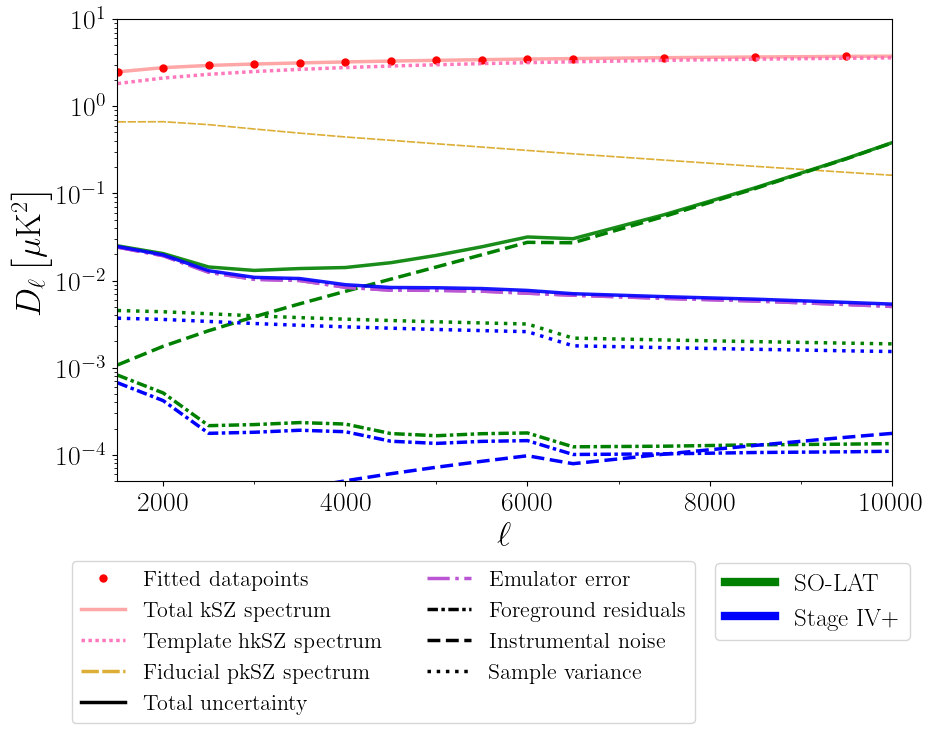

In [94]:
fig, ax = plt.subplots(1,1, figsize=(10,6))
fig.subplots_adjust(wspace=0.0)

from matplotlib.ticker import LinearLocator, MultipleLocator

from matplotlib.lines import Line2D

from alfred.parameters import colors

lw = 2.5

legend_lines = [
    Line2D([0], [0], color='black', linestyle=':', alpha=1.0, lw=lw, label='Sample variance'),
    Line2D([0], [0], color='black', linestyle='--', alpha=1.0, lw=lw, label='Instrumental noise'),
    Line2D([0], [0], color='black', linestyle=(0, (3, 1, 1, 1)), lw=lw, alpha=1.0, label='Foreground residuals'),
    Line2D([0], [0], color='mediumorchid', linestyle='dashdot', lw=lw, alpha=1.0, label='Emulator error'),
    Line2D([0], [0], color='black', linestyle='-', alpha=1.0, lw=lw, label='Total uncertainty'),
    Line2D([0], [0], color=colors[3], linestyle=(0, (5, 1)), alpha=.9, linewidth=lw, label=f'Fiducial pkSZ spectrum'),
    Line2D([0], [0], color='hotpink', linestyle=(0, (1, 1)), alpha=.9, linewidth=lw, label=f'Template hkSZ spectrum'),
    Line2D([0], [0], color='red', linestyle='-', alpha=.35, linewidth=lw, label=f'Total kSZ spectrum'),
    Line2D([0], [0], color='red', linestyle='', marker='.', alpha=1.0, markersize=10, label=f'Fitted datapoints')  # alpha > 1 will be clipped to 1
]

data = np.load(f"{base_dir}/inference/productionruns6_addhksz/CMB-HD/noiseless/data.npz")
hksz = np.genfromtxt(f"{base_dir}/metadata/dl_ksz_hom_AG.dat").T
hksz = np.interp(ells[indices], hksz[0], hksz[1])

fiducial = utils.spectra(config.sn)[indices] + 2.5 * hksz

ax.plot(ells[indices], fiducial, color='red', alpha=.35, lw=lw)
ax.plot(ells[indices], fiducial, color='red', marker='.', ls='', markersize=10)

ax.plot(ells[indices], utils.spectra(config.sn)[indices], color=colors[3], alpha=.9, ls=(0, (5, 1)), lw=1.2)
ax.plot(ells[indices], 2.5 * hksz, color='hotpink', alpha=.9, ls=(0, (1, 1)), lw=lw)

color_labels = []
color_rects = []

for i, tele in enumerate(['SO-LAT', 'CMB-HD']):

    # ax[i].plot(ells[indices], fiducial, color='black', alpha=.35)
    # ax[i].plot(ells[indices], fiducial, color='black', marker='.', ls='')

    # ax[i].plot(ells[indices], utils.spectra(config.sn)[indices], color='black', alpha=.35, ls=(0, (5, 1)))
    # ax[i].plot(ells[indices], 2.5 * hksz, color='black', alpha=.35, ls=(0, (1, 1)))
    
    # Sample variance
    cov = alfred.surveys.error_cov(ells[indices], fiducial, alfred.surveys.telescopes[tele],
                                   include_samplevar=True)
    err = np.sqrt(np.diag(cov))
    ax.plot(ells[indices], err, color=colors[i], ls=':', lw=lw)

    # print(f"Sample variance for {tele} is:")
    # print(err)
    # print()

    # Foreground residuals
    cov = alfred.surveys.error_cov(ells[indices], fiducial, alfred.surveys.telescopes[tele],
                                   include_fgresiduals=True)
    err = np.sqrt(np.diag(cov))
    ax.plot(ells[indices], err, #label='sample variance' if i == 2 else None,
                color=colors[i], ls=(0, (3, 1, 1, 1)), lw=lw)

    # print(f"Fg residuals for {tele} is:")
    # print(err)
    # print()

    # Instrumental noise
    cov = alfred.surveys.error_cov(ells[indices], fiducial, alfred.surveys.telescopes[tele],
                                   include_noise=True)
    err = np.sqrt(np.diag(cov))
    ax.plot(ells[indices], err, # if i == 2 else None,
                color=colors[i], ls='--', lw=lw)

    # print(f"Noise for {tele} is:")
    # print(err)
    # print()

    cov = alfred.surveys.error_cov(ells[indices], fiducial, alfred.surveys.telescopes[tele],
                                   include_emulator=True,)
    err = np.sqrt(np.diag(cov))
    ax.plot(ells[indices], err, #label='sample variance' if i == 2 else None,
                color='mediumorchid', ls='dashdot', lw=lw)

    # print(f"Emulator err for {tele} is:")
    # print(err)
    # print()
    
    # Total uncertainty
    cov = alfred.surveys.error_cov(ells[indices], fiducial, alfred.surveys.telescopes[tele],
                                   include_emulator=True, include_noise=True,
                                   include_samplevar=True, include_fgresiduals=True)
    err = np.sqrt(np.diag(cov))
    ax.plot(ells[indices], err, #label='emulator error' if i == 2 else None,
                color=colors[i], alpha=.9, lw=lw)

    if tele == 'CMB-HD':
        color_labels.append('Stage IV+')
    else:
        color_labels.append(tele)

    color_rects.append(Line2D([0], [0], color=colors[i], lw=6, label=color_labels[i]))
#     ax[i].set_title(f'{tele}', fontsize=16)
#     ax[i].set_xlabel(rf"$\ell$", fontsize=16)

#     ax[3].plot(ells[indices], err, color=colors[i])

# ax[2].plot([],[])

# ax[3].set_title(f'Comparison', fontsize=16)
ax.set_xlabel(rf"$\ell$", fontsize=25)

ax.set_xlim(1490, 10000)
#ax[0].set_ylabel(r'$\ell(\ell+1)C_\ell^{kSZ}/2\pi$')
ax.set_ylabel(r'$D_\ell \left[\mathrm{\mu K^2} \right]$', fontsize=25)
ax.set_ylim(5e-5,10)
#ax[0].set_xscale('log')
ax.set_yscale('log')
ax.tick_params(axis='both', labelsize=20)

# Second legend for the colored rectangles
# Add it to the same plot
legend1 = ax.legend(handles=color_rects, loc='upper right', fontsize=18 , bbox_to_anchor=(1.04, -0.15))

ax.xaxis.set_major_locator(MultipleLocator(2000))
ax.xaxis.set_minor_locator(MultipleLocator(1000))

ax.add_artist(legend1)
ax.legend(handles=legend_lines[::-1], loc='upper right', fontsize=16, bbox_to_anchor=(.76, -0.15), ncols=2)

fig.savefig('surveys.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)


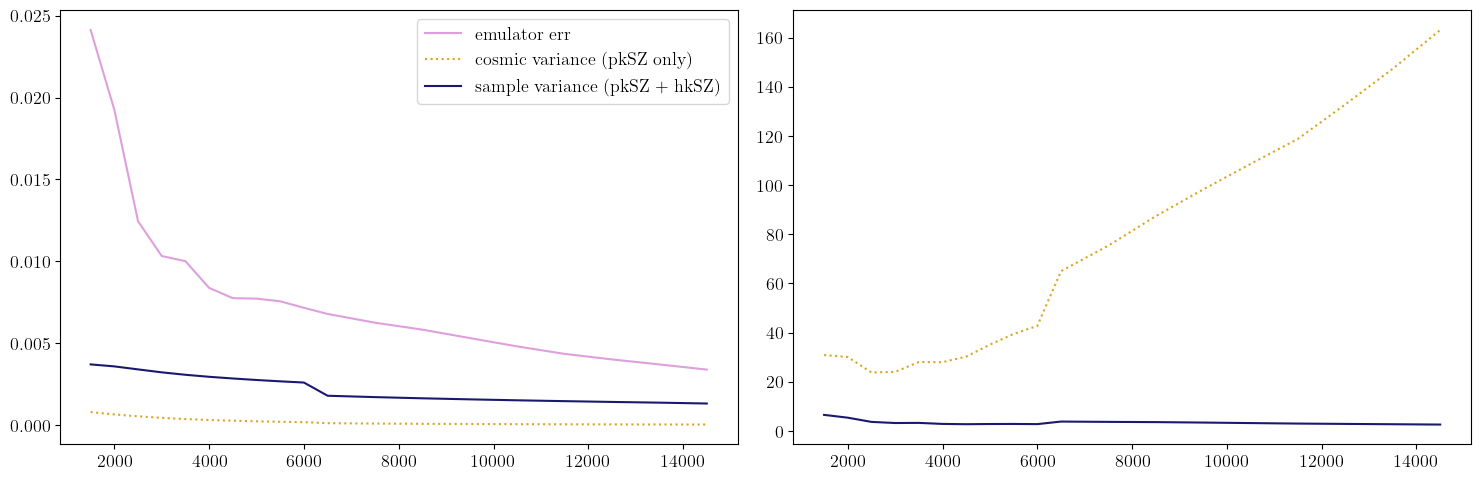

In [22]:
fig, ax = plt.subplots(1,2, figsize=(12,5))


cov_emu = alfred.surveys.error_cov(ells[indices], fiducial, alfred.surveys.telescopes[tele],
                                   include_emulator=True)
err_emu = np.sqrt(np.diag(cov_emu))
ax[0].plot(ells[indices], err_emu, color=colors[2], ls='-', label='emulator err')

cov = alfred.surveys.error_cov(ells[indices], emulator.kemu(df.loc[config.sn].to_numpy(), mob),
                               alfred.surveys.telescopes['cosmic'],
                                include_emulator=False, include_noise=False, include_samplevar=True)
err = np.sqrt(np.diag(cov))
ax[0].plot(ells[indices], err, color=colors[3], ls=':', label='cosmic variance (pkSZ only)')
ax[1].plot(ells[indices], err_emu / err, color=colors[3], ls=':')

cov = alfred.surveys.error_cov(ells[indices], fiducial, alfred.surveys.telescopes[tele],
                                   include_samplevar=True)
err = np.sqrt(np.diag(cov))
ax[0].plot(ells[indices], err, color=colors[4], ls='-', label='sample variance (pkSZ + hkSZ)')
ax[1].plot(ells[indices], err_emu / err, color=colors[4], ls='-')


ax[0].legend()
fig.tight_layout()

### Ionisation Histories and the Optical Depth, $\tau$

In [288]:
xe_histories = np.load(f"{base_dir}/metadata/xe_histories_from_spectra.npz", allow_pickle=True)
xe_histories = xe_histories['arr_0'].item()

In [ ]:
fig.savefig('xion_tau.png')

In [ ]:
diff, Planck_sn

(np.float64(0.014014080573021143), '15060')

In [ ]:
sim = Cat(Planck_sn, skip_early=True,
                        base_dir=base_dir,
                        path_spectra=spectra_path,
                        path_redshifts=redshift_file,
                        LoReLi_format=True,
                        verbose=False)
    
ksz = KSZ.KSZ_power(verbose=False, interpolate_xe=True, interpolate_Pee=True,
                    helium_interp=True, Pee_data=sim.Pee, xe_data=sim.xe, z_data=sim.z, k_data=sim.k,
                    xemax=.97)
        

fn = f'{home_dir}/nells30_v2/kSZ_LoReLi_simu{Planck_sn}.npz'
LoReLi = np.load(fn)

print(f"tau:{ksz.tau:.3f}")
print(f"tau:{ksz.tau + diff:.3f}")

tau:0.040
tau:0.054


## Mock Data
### Fiducial simulation

##### Homogeneous kSZ

In [6]:
true_params = np.asarray([*df.loc[config.sn].to_numpy(), *whatthetau(df.loc[config.sn].to_numpy())])
true_params

/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:151: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


array([-1.71669877,  0.        ,  3.27712767,  8.53      ,  0.275     ,
        0.05526446])

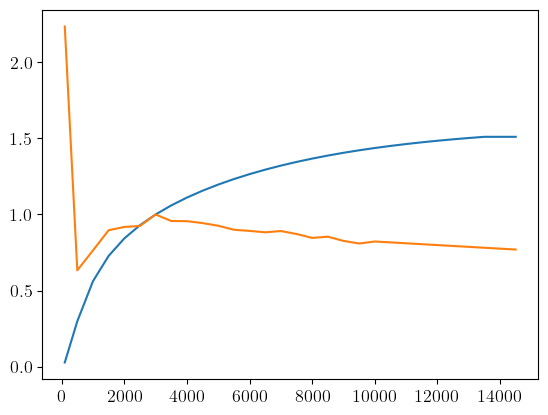

In [7]:
hksz = np.genfromtxt(f"{base_dir}/metadata/dl_ksz_hom_AG.dat").T
hksz = np.interp(ells, hksz[0], hksz[1])

hksz2 = np.genfromtxt(f"{base_dir}/metadata/dl_homogeneous_ksz_shaw2012.txt").T
hksz2 = np.interp(ells, hksz2[0], hksz2[1])

plt.plot(ells, hksz)
plt.plot(ells, hksz2)

## Emulator performance and stability

Loading in our chosen emulator

### kSZ emulator

In [46]:
validation_sims = np.load(f'{base_dir}/emulators/setrandomseed3/validation_sims.npy', allow_pickle=True)

In [52]:
true_spec = np.zeros((len(validation_sims), len(ells[indices])))
emu_spec = np.zeros_like(true_spec)

for i, sn in enumerate(validation_sims):
    if i % 200 == 0:
        print(f"On {i}/{len(validation_sims)}...")
    true_spec[i] = utils.spectra(sn)[indices]
    emu_spec[i] = emulator.kemu(df.loc[sn].to_numpy(), mob)

On 0/1359...
On 200/1359...
On 400/1359...
On 600/1359...
On 800/1359...
On 1000/1359...
On 1200/1359...


In [ ]:
np.mean(np.mean(ratios_all, axis=0), axis=0)

In [71]:
1 / np.mean(emu_spec / true_spec)

np.float64(0.9970109108619698)

In [74]:
np.mean(emu_spec / true_spec) / np.mean(emu_spec / true_spec, axis=0)

array([1.00089062, 1.00229598, 1.00173614, 1.00061226, 0.99996432,
       0.99992722, 1.00035163, 1.00038532, 1.00032646, 0.99995296,
       0.99987656, 0.99924279, 0.99929393, 0.99897289, 0.99895411,
       0.99925434, 0.99909702, 0.9994802 , 0.9994003 ])

(0.98, 1.02)

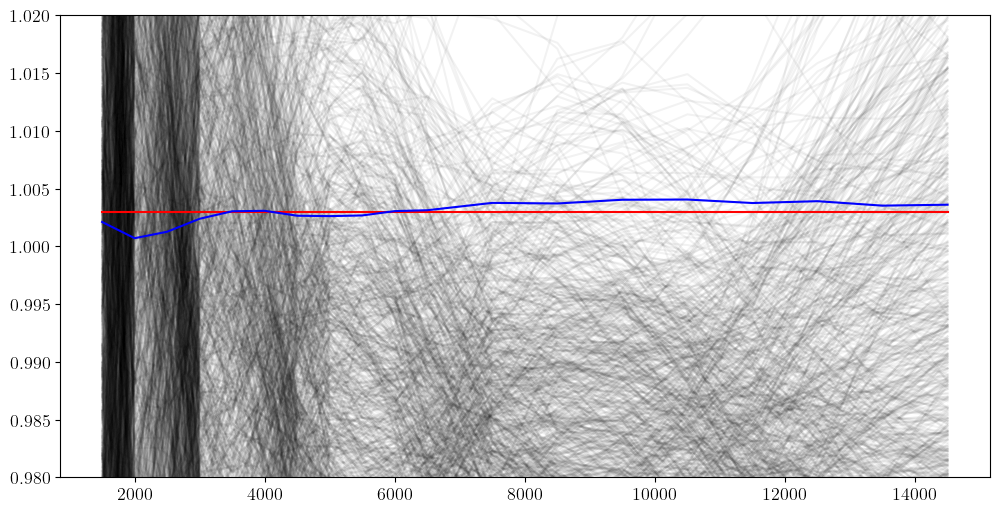

In [77]:
fig, ax = plt.subplots( figsize=(12,6))

l = ax.plot(ells[indices], (emu_spec / true_spec).T, alpha=.05, color='black')

l = ax.plot(ells[indices], np.mean(emu_spec / true_spec) * np.ones_like(ells[indices]), alpha=1.0, color='red')
l = ax.plot(ells[indices], np.mean(emu_spec / true_spec, axis=0), alpha=1.0, color='blue')

ax.set_ylim(.98,1.02)

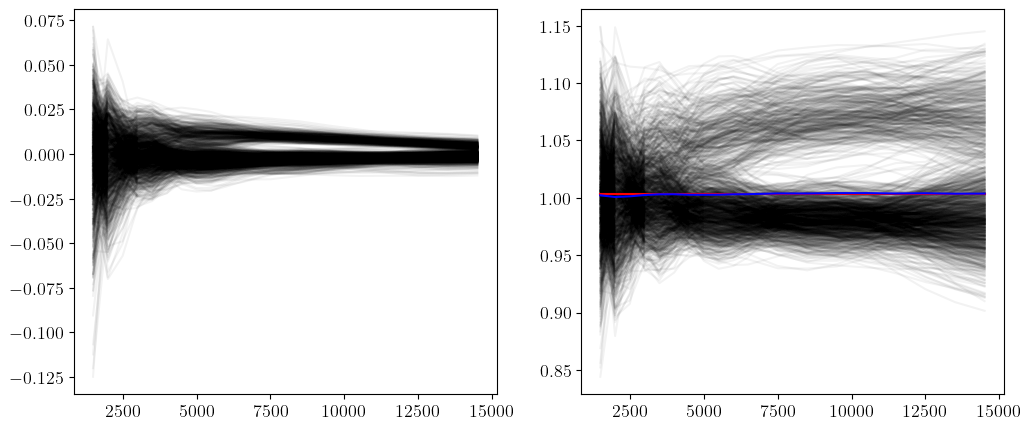

In [67]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

l = ax[0].plot(ells[indices], (emu_spec - true_spec).T, alpha=.05, color='black')
l = ax[1].plot(ells[indices], (emu_spec / true_spec).T, alpha=.05, color='black')

l = ax[1].plot(ells[indices], np.mean(emu_spec / true_spec) * np.ones_like(ells[indices]), alpha=1.0, color='red')
l = ax[1].plot(ells[indices], np.mean(emu_spec / true_spec, axis=0), alpha=1.0, color='blue')

plotting 39 sims...


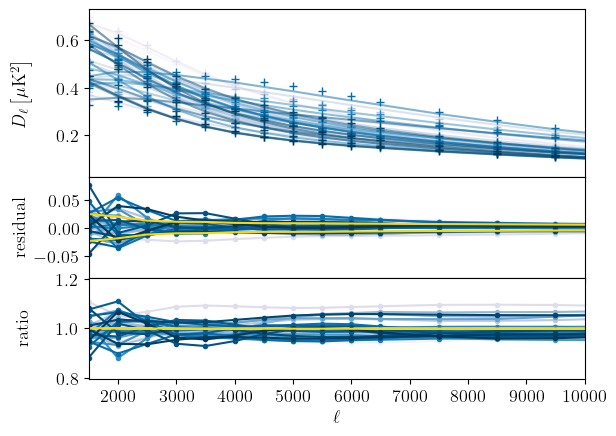

In [16]:
fig, ax = plt.subplots(3, 1, sharex=True, gridspec_kw={'height_ratios': [5, 3, 3]})
fig.subplots_adjust(wspace=0.0, hspace=0.0)

skipping = 35
sims_to_plot = validation_sims[::skipping]
print(f"plotting {len(sims_to_plot)} sims...")

N = len(sims_to_plot)
cmap = matplotlib.colormaps['PuBu']
    
# Generate N evenly spaced values in [0, 1]
ksz_colors = [cmap(i / (N - 1)) for i in range(N)]

data_ref = np.load(f"{base_dir}/inference/productionruns2_mechaemu/CMB-HD/noiseless/data.npz")
std = np.load(f"{base_dir}/emulators/{config.nndir}/ensemble_error_v5.1.npy")

for i, sn in enumerate(sims_to_plot):
    tspec = utils.spectra(sn)[indices]
    espec = emulator.kemu(df.loc[sn].to_numpy(), mob)

    ax[0].plot(ells[indices], tspec, marker='+', ls='', color=ksz_colors[i])
    ax[0].plot(ells[indices], espec, alpha=.5, color=ksz_colors[i])

    ax[1].plot(ells[indices], tspec - espec, marker='.', color=ksz_colors[i])
    ax[2].plot(ells[indices], espec / tspec, marker='.', color=ksz_colors[i])
    ax[2].plot(ells[indices], data_ref['Ashape'], color='gold')

ax[1].plot(ells[indices], -std, color='gold')
ax[1].plot(ells[indices], std, color='gold')

# a1.plot(x, y)
# a2.plot(x, y)

ax[0].set_xlim(1500,10000)
ax[1].set_ylim(-.09, .09)
ax[2].set_ylim(.795, 1.205)

ax[2].set_xlabel(rf"$\ell$")

ax[0].set_ylabel(r"$D_\ell \left[\mathrm{\mu K^2} \right]$")
ax[1].set_ylabel(rf"$\mathrm{{residual}}$")
ax[2].set_ylabel(rf"$\mathrm{{ratio}}$")

ax[0].yaxis.set_label_coords(-0.115, 0.5) 
ax[2].yaxis.set_label_coords(-0.115, 0.5) 

fig.savefig("NNemulator.png", bbox_inches='tight', pad_inches=0.05, dpi=300)

plotting 39 sims...


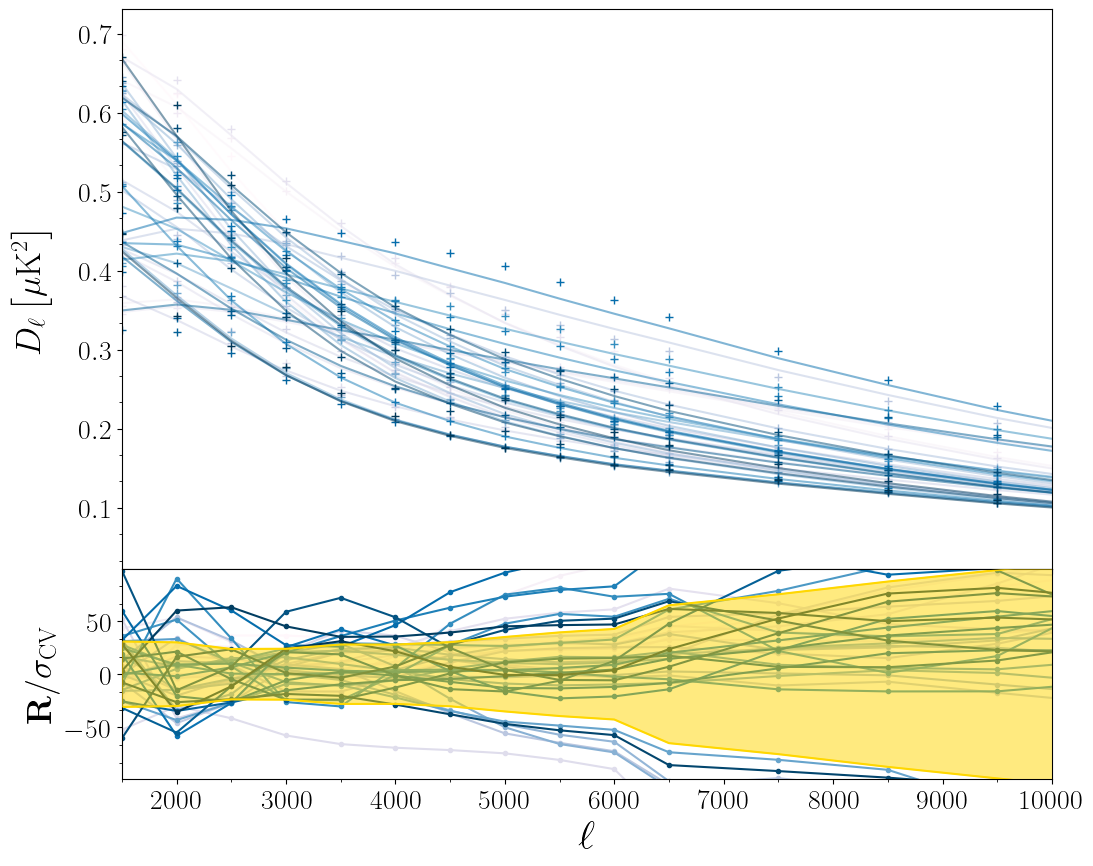

In [42]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(12,10), gridspec_kw={'height_ratios': [8, 3]})
fig.subplots_adjust(wspace=0.0, hspace=0.0)

from matplotlib.ticker import LinearLocator, MultipleLocator, AutoMinorLocator, MaxNLocator

skipping = 35
sims_to_plot = validation_sims[::skipping]
print(f"plotting {len(sims_to_plot)} sims...")

N = len(sims_to_plot)
cmap = matplotlib.colormaps['PuBu']
    
# Generate N evenly spaced values in [0, 1]
ksz_colors = [cmap(i / (N - 1)) for i in range(N)]

data_ref = np.load(f"{base_dir}/inference/productionruns2_mechaemu/CMB-HD/noiseless/data.npz")
std = np.load(f"{base_dir}/emulators/{config.nndir}/ensemble_error_v5.1.npy")

cov = alfred.surveys.error_cov(ells[indices], emulator.kemu(df.loc[config.sn].to_numpy(), mob),
                               alfred.surveys.telescopes['cosmic'],
                                include_emulator=False, include_noise=False, include_samplevar=True)
err = np.sqrt(np.diag(cov))

for i, sn in enumerate(sims_to_plot):
    tspec = utils.spectra(sn)[indices]
    espec = emulator.kemu(df.loc[sn].to_numpy(), mob)

    ax[0].plot(ells[indices], tspec, marker='+', ls='', color=ksz_colors[i])
    ax[0].plot(ells[indices], espec, alpha=.5, color=ksz_colors[i])

    ax[1].plot(ells[indices], (tspec - espec) / err, marker='.', color=ksz_colors[i])
#    ax[2].plot(ells[indices], espec / tspec, marker='.', color=ksz_colors[i])
#    ax[2].plot(ells[indices], data_ref['Ashape'], color='gold')

ax[1].plot(ells[indices], -std /err, color='gold')
ax[1].plot(ells[indices], std /err, color='gold')
ax[1].fill_between(ells[indices], -std/err, std/err, alpha=.5, color='gold', zorder=5)

# a1.plot(x, y)
# a2.plot(x, y)

ax[0].set_xlim(1500,10000)
ax[1].set_ylim(-99, 99)
#ax[2].set_ylim(.795, 1.205)

ax[1].set_xlabel(rf"$\ell$", fontsize=30)

ax[0].set_ylabel(r'$D_\ell \left[\mathrm{\mu K^2} \right]$', fontsize=25, labelpad=20) #, labelpad=-20,rotation=90)
ax[1].set_ylabel(r"${\mathbf{R}}/{\sigma_{\mathrm{CV}}}$", fontsize=25) #, labelpad=0, va='center')
# ax[2].set_ylabel(r"$\frac{y_{\mathrm{emu}}}{y_{\mathrm{true}}}$", labelpad=0, va='center')
ax[0].tick_params(axis='both', labelsize=20)
ax[1].tick_params(axis='both', labelsize=20)
# ax[0].yaxis.set_label_coords(-0.115, 0.5) 
#ax[2].yaxis.set_label_coords(-0.115, 0.5) 
    
ax[1].xaxis.set_minor_locator(AutoMinorLocator(2))
ax[0].yaxis.set_minor_locator(AutoMinorLocator(3))
ax[1].yaxis.set_minor_locator(AutoMinorLocator(3))
fig.savefig("NNemulator.pdf", bbox_inches='tight', pad_inches=0.05, dpi=300)

In [58]:
def degeneracy(Mmin, slope=priors2d['m'], intercept=priors2d['b_below']):
    return priors2d['m'] * Mmin + priors2d['b_below']

xMmin = np.linspace(*priors[3],10)
xtau = degeneracy(xMmin)

In [32]:
NN_settings = np.load('/Users/emcbride/Datasets/LoReLi/emulators/setrandomseed3/emuv5.1_run0/training_files.npz', allow_pickle=True)

In [33]:
for key in NN_settings.keys():
    print(key, NN_settings[key])

X_train [[-2.71669877  0.6         3.18087105  9.07        0.05      ]
 [-2.05018079  0.4         3.29473069  9.33        0.275     ]
 [-3.05394094  0.6         3.48725153  8.27        0.275     ]
 ...
 [-3.37427609  0.          3.48725153  8.27        0.5       ]
 [-2.88418986  0.2         3.07874673  9.33        0.5       ]
 [-2.21701169  0.6         3.40861303  9.6         0.5       ]]
X_test [[-2.21701169  0.8         3.69738629  8.          0.05      ]
 [-1.71669877  0.2         3.48725153  8.27        0.5       ]
 [-2.05018079  0.2         3.49312331  8.53        0.05      ]
 ...
 [-3.54060751  0.          3.81712887  8.53        0.275     ]
 [-2.05018079  0.          3.58937984  8.          0.275     ]
 [-2.21701169  0.6         3.28887495  9.07        0.5       ]]
y_train [[0.42349304 0.39855623 0.39675264 ... 0.12717576 0.11170471 0.09759528]
 [0.58459714 0.5146753  0.44612404 ... 0.0969823  0.08572519 0.07507629]
 [0.57000014 0.51798042 0.45625133 ... 0.08947331 0.07861217 0.

/Users/emcbride/miniforge3/envs/alfred/lib/python3.11/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/var/folders/8t/k878xr_j2fqgy_993tg3qy7c0000gn/T/ipykernel_76328/910443812.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('viridis')
/var/folders/8t/k878xr_j2fqgy_993tg3qy7c0000gn/T/ipykernel_76328/910443812.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` o

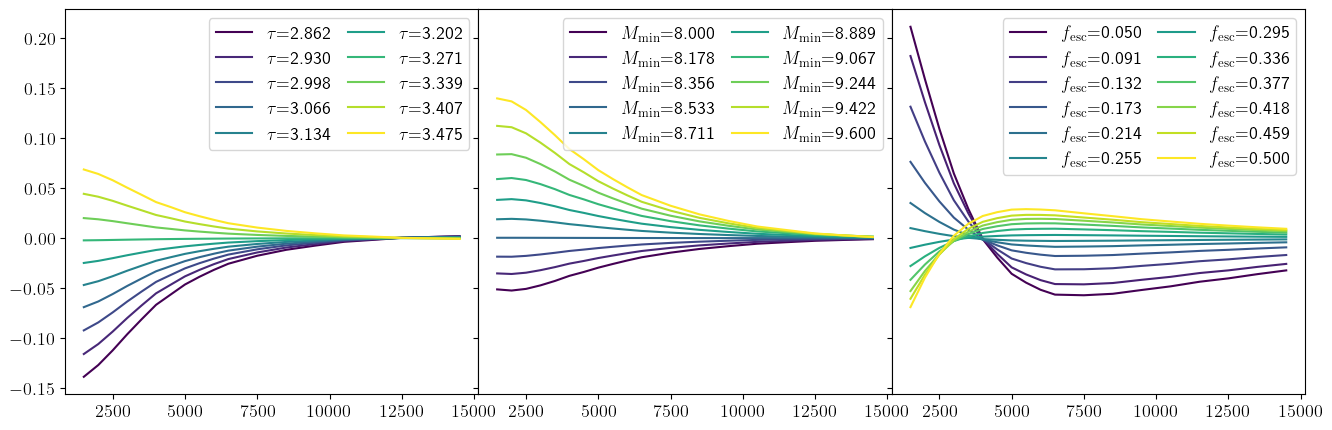

In [79]:
fig, ax = plt.subplots(1,3, sharex=True, sharey=True, figsize=(16,5))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

params_x = [xtau[::-1], xMmin, xfesc]

for i_param, prange in enumerate(params_x):
    N = len(prange)
    cmap = matplotlib.cm.get_cmap('viridis')
    
    # Generate N evenly spaced values in [0, 1]
    colors = [cmap(i / (N - 1)) for i in range(N)]
    for it, t in enumerate(prange):
        params = cp.deepcopy(true_params[:-1])
        params[2+i_param] = t
        espec = emulator.mechkemu(params, mob)
        label = rf"{astro_pnames_formatted[2+i_param]}$=${t:.3f}"
        ax[i_param].plot(ells[indices], tspec - espec, color=colors[it], label=label)
        ax[i_param].legend(ncol=2, columnspacing=1.0, fontsize=13)

fig.savefig('x_vs_dkSZ.png', bbox_inches='tight', pad_inches=0.05, dpi=300)

In [44]:
samples

array([[-2.79721189,  0.19627005,  3.66770594,  8.04797253,  0.42621474],
       [-2.32323812,  0.17636773,  3.31828961,  9.55882617,  0.13174127],
       [-3.66792151,  0.11632865,  3.27298402,  8.83525598,  0.1073423 ],
       ...,
       [-2.84047047,  0.03494826,  3.18765722,  9.52513095,  0.06699478],
       [-2.53079057,  0.13263233,  3.92487386,  8.11045816,  0.27302342],
       [-3.03547066,  0.5471112 ,  3.46611226,  8.64786835,  0.34987466]],
      shape=(1000, 5))

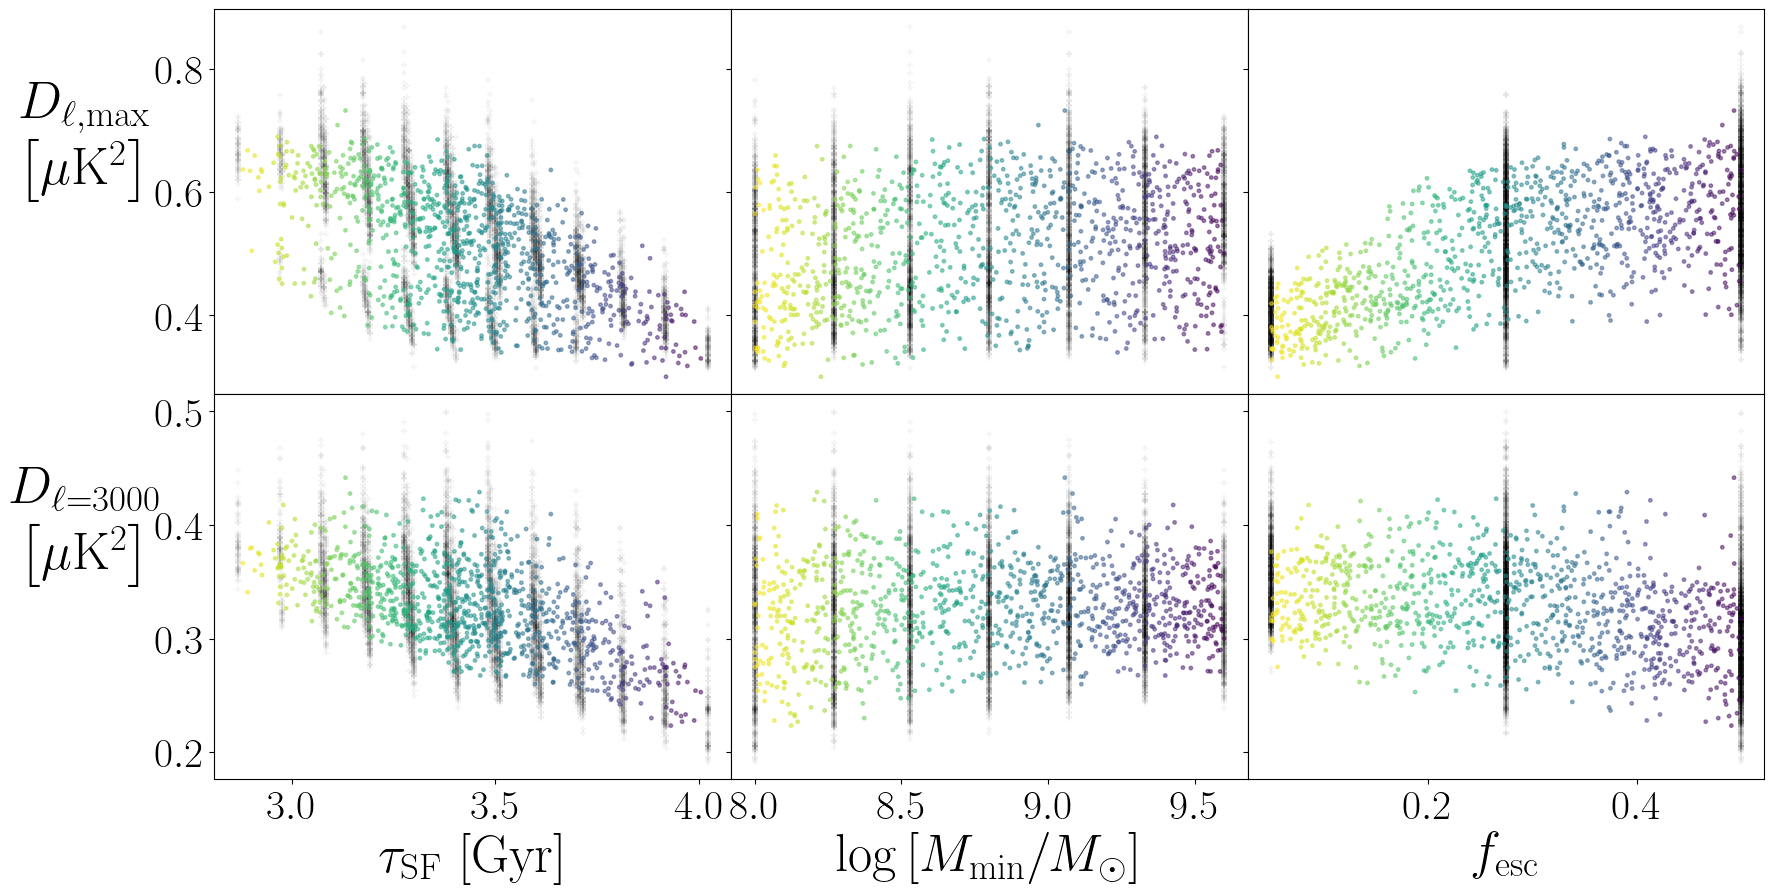

In [38]:
fig, ax = plt.subplots(2,len(df.columns.to_list()[2:]), sharex='col', sharey='row', figsize=(20,10))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

norm = matplotlib.colors.Normalize(vmin=df["rHS"].min(), vmax=df["rHS"].max())
cmap = plt.get_cmap('viridis_r')

samples = draws(1000)

params = df.to_numpy()
data = np.zeros((len(df), len(ells[indices])))
for i_sim, sn in enumerate(df.index):
    data[i_sim] = utils.spectra(sn)[indices]
    
signal = emulator.kemu(samples, mob)
color = cmap(norm(params[-1]))

skwargs = {'marker':'.', 
           's':25,
           'alpha':.5,
           'color':color,
           'rasterized': True}

for i, pname in enumerate(df.columns.to_list()[2:]):
    skwargs['marker'] = '+'
    skwargs['alpha'] = .04
    skwargs['color'] = 'black'

    ax[0,i].scatter(params[:,2+i], np.max(data, axis=1), **skwargs)
    # ax[1,i].scatter(params[:,i], ells[indices][np.argmax(data[:,1:], axis=1)], **skwargs)
    ax[1,i].scatter(params[:,2+i], data[:,4], **skwargs)

    skwargs['color'] = cmap(norms[2+i](samples[:,2+i]))
    skwargs['marker'] = '.'
    skwargs['alpha'] = .5

    ax[0,i].scatter(samples[:,2+i], np.max(signal, axis=1), **skwargs)
    # ax[1,i].scatter(samples[:,i], ells[indices][np.argmax(signal, axis=1)], **skwargs)
    ax[1,i].scatter(samples[:,2+i],  signal[:,4], **skwargs)

    ax[1,i].set_xlabel(astro_wunits[2+i], fontsize=38)

[a.tick_params(axis='both', labelsize=30) for a in ax.flatten()]

ax[0, 0].set_ylabel(r"$\begin{array}{c}D_{\ell, \mathrm{max}} \\ \left[ \mathrm{\mu K^2} \right]\end{array}$", fontsize=38, rotation=0, labelpad=50)
# ax[1, 0].set_ylabel(r"$\ell_{\mathrm{max}}$", fontsize=30, rotation=0, labelpad=50)
ax[1, 0].set_ylabel(r"$\begin{array}{c}D_{\ell=3000} \\ \left[\mathrm{\mu K^2} \right]\end{array}$", fontsize=38, rotation=0, labelpad=50)

# ax[1,0].set_ylim(1000, 3000)

fig.savefig('trends2.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)



### 

### X_e emulator

In [145]:
xe_histories = np.load(f'{home_dir}/alfred/ionisation_histories_with_optical_depth.npz', allow_pickle=True)
xe_histories = xe_histories['arr_0'].item()

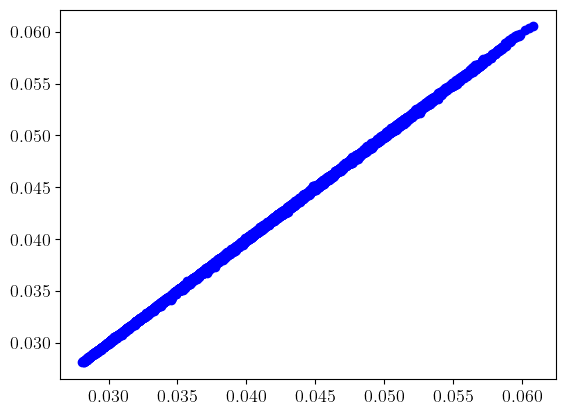

In [156]:
fig = plt.figure()

residuals = []

for key, item in xe_histories.items():
    temu = item['tau_emu']
    demu = item['tau_data']

    residuals.append(np.abs(temu - demu))

    plt.scatter(demu, temu, color='blue')
    

In [157]:
np.mean(residuals)

np.float64(7.448011129040616e-05)

# Section 4     Results

### Gorce hkSZ template

In [4]:
mcmcdir = f"{base_dir}/inference/productionruns7_addhksz"
survey_list = ['SO-LAT', 'CMB-HD'] # 'CMB-S4', 
data = np.load(f"{mcmcdir}/{survey_list[1]}/noiseless/data.npz")

chains = []

# s, l = utils.load_samples(f"{base_dir}/inference/productionruns6_justpriors/CMB-HD/noiseless")
# chains.append(s)

# fig, ax = plt.subplots(1,3, figsize=(10,3))
# fig.subplots_adjust( wspace=0.0, hspace=0.0)

# norm = matplotlib.colors.Normalize(vmin=df["rHS"].min(), vmax=df["rHS"].max())
# cmap = plt.get_cmap('viridis_r')

# ztau = np.linspace(5,15,10)

for i, s in enumerate(survey_list):
    s, l = utils.load_samples(f"{mcmcdir}/{s}/noiseless")
    print(f"shape:", s.shape)
    chains.append(s)
    # params = fill(s, df.loc[config.sn].to_dict(), df.columns[2:])
    # xe = keras_xe_emul.xe_emul_array(ztau, params, plot=False)

    # for n in range(1,10000,1000):
    #     ax[i].semilogy(ztau, xe[n].T, color=cmap(norm(params[n,-1])))



Loading samples from /data/cluster/emc-brid/Datasets/LoReLi/inference/productionruns7_addhksz/SO-LAT/noiseless...
shape: (120000, 5)
Loading samples from /data/cluster/emc-brid/Datasets/LoReLi/inference/productionruns7_addhksz/CMB-HD/noiseless...
shape: (120000, 5)


1.0043749667716018


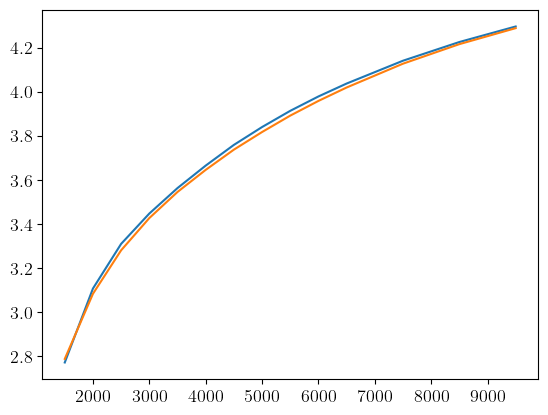

In [5]:
plt.plot(data['ells'], data['datapoints'])
plt.plot(data['ells'], data['model'])

print(np.mean(data['datapoints'] / data['model']))

In [6]:
# pnames = [*df.columns[2:], 'tau_CMB', 'A', 'A_hksz']
# pnames = [
#     r"$\tau_{\mathrm{SF}}$ [Gyr]",
#     r"$\log{[M_{\mathrm{min}}/M_{\odot}]}$",
#     r"$f_{\mathrm{esc}}$",
#     r"$\tau_{\mathrm{CMB}}$",
#     r"$A_{\mathrm{bias}}$ ",
#     r'$A_{\mathrm{hkSZ}}$ [$\mu \mathrm{K}^2$]']

true_params = [*df.loc[config.sn].to_numpy()]
true_params[2] = true_params[2] - np.log10(1e2)
true_values = dict(zip(astro_wunits[2:], [*true_params[2:],
                                *whatthetau(df.loc[config.sn].to_numpy()),
                                np.mean(utils.spectra(config.sn)[indices] / alfred.emulator.kemu(df.loc[config.sn].to_numpy(), mob)),
                                2.9]))

/home/emc-brid/alfred/src/alfred/keras_xe_emul.py:172: RuntimeWarning: divide by zero encountered in log10
  np.log10(zvect),


In [7]:
true_values

{'$\\log{[\\tau_{\\mathrm{SF}}/\\mathrm{Gyr}]}$': np.float64(1.277127671229863),
 '$\\log{[M_{\\mathrm{min}}/M_{\\odot}]}$': np.float64(8.53),
 '$f_{\\mathrm{esc}}$': np.float64(0.275),
 '$\\tau_{\\mathrm{CMB}}$': np.float64(0.05513605350367262),
 '$A_{\\mathrm{bias}}$ ': np.float64(1.0463108657906013),
 '$A_{\\mathrm{hkSZ}}$': 2.9}

In [8]:
from itertools import islice

small_dict = dict(islice(true_values.items(), 4))
small_dict

{'$\\log{[\\tau_{\\mathrm{SF}}/\\mathrm{Gyr}]}$': np.float64(1.277127671229863),
 '$\\log{[M_{\\mathrm{min}}/M_{\\odot}]}$': np.float64(8.53),
 '$f_{\\mathrm{esc}}$': np.float64(0.275),
 '$\\tau_{\\mathrm{CMB}}$': np.float64(0.05513605350367262)}

In [9]:
s = np.load(f"{base_dir}/inference/productionruns7_addhksz/samples_addtauCMB/samples_priors_hypercube.npy")

nbins = 30
chainpriors = make_tauchains(s[:,:3], A=False, dropA=False, truths=df.loc[config.sn].to_dict())
#prior_hists = [np.histogram(row, bins=30, density=True) for row in chainpriors.T]

/home/emc-brid/alfred/src/alfred/keras_xe_emul.py:172: RuntimeWarning: divide by zero encountered in log10
  np.log10(zvect),


In [10]:
chainpriors[:,0] = chainpriors[:,0] - np.log10(1e2)
chainpriors

array([[1.23621898, 8.67799497, 0.3334571 , 0.05683524],
       [1.53741065, 8.10990972, 0.45663603, 0.05629628],
       [1.00401307, 9.32912757, 0.4288977 , 0.05624982],
       ...,
       [1.18415015, 9.52236502, 0.10319372, 0.03718776],
       [1.26552837, 9.01480567, 0.19576864, 0.04545626],
       [1.14490334, 9.12340466, 0.43085577, 0.05575089]])

In [10]:
def summary_statistics(means, truths, low68, high68):
    edges68 = []
    for i in range(means.shape[0]):
        low = low68[i]
        high = high68[i]
    
        edges68.append((low, high))

    if means.ndim == 1:
        intervals68 = edges68 - np.stack([means, means], axis=1)
        biases = (means - truths[2:])
        sigma_max_68 = np.max(np.abs(intervals68), axis=1)
    else:
        intervals68 = edges68 - np.stack([means, means], axis=1)
        intervals68 = np.swapaxes(intervals68, 1, 2)
    # for i in range(means.shape[0]):
    #     low = low95[i]
    #     high = high95[i]
        
    #     edges95.append((low, high))
    
    # intervals95 = edges95 - np.stack([means, means], axis=1)
    # intervals95 = np.swapaxes(intervals95, 1, 2)

        biases = (means - truths[:,2:])
        sigma_max_68 = np.max(np.abs(intervals68), axis=2)

    return biases, sigma_max_68

In [17]:
ci = 68
lower_q = (100 - ci) / 2
upper_q = 100 - lower_q

In [106]:
true_values

{'$\\tau_{\\mathrm{SF}}$ [Gyr]': np.float64(1.277127671229863),
 '$\\log{[M_{\\mathrm{min}}/M_{\\odot}]}$': np.float64(8.53),
 '$f_{\\mathrm{esc}}$': np.float64(0.275),
 '$\\tau_{\\mathrm{CMB}}$': np.float64(0.05513605350367262),
 '$A_{\\mathrm{bias}}$ ': np.float64(1.0463108657906013),
 '$A_{\\mathrm{hkSZ}}$ [$\\mu \\mathrm{K}^2$]': 2.9}

In [34]:
for i, chain in enumerate(chains):
    chaintau = make_tauchains(chain[:,:3], A=False, dropA=False, truths=df.loc[config.sn].to_dict())
    chaintau = cp.deepcopy(np.concatenate([chaintau,chain[:,3:]], axis=1))
    chaintau[:,0] += - np.log10(1e2)
    means = chaintau.mean(axis=0)

    low, high = np.percentile(chaintau, [lower_q, upper_q], axis=0)
    for i, m in enumerate(means):
        print(f"for {list(true_values.keys())[i]}")
        t = list(true_values.values())[i]
        if i < 4:
            pass
        if (high[i]- m) > (m - low[i]):
            sigma = (high[i]- m)
        else:
            sigma = (m - low[i])

        print(f"mean {m:.5f} and true {t:.5f} and sigma {sigma:.5f}")
        print(f" nb is {((m - t) / sigma):.5f}")

    print()
    

for $\tau_{\mathrm{SF}}$ [Gyr]
mean 1.29746 and true 1.27713 and sigma 0.19728
 nb is 0.10305
for $\log{[M_{\mathrm{min}}/M_{\odot}]}$
mean 8.71947 and true 8.53000 and sigma 0.49469
 nb is 0.38300
for $f_{\mathrm{esc}}$
mean 0.33012 and true 0.27500 and sigma 0.07210
 nb is 0.76443
for $\tau_{\mathrm{CMB}}$
mean 0.05363 and true 0.05514 and sigma 0.00221
 nb is -0.68072
for $A_{\mathrm{bias}}$ 
mean 1.01129 and true 1.04631 and sigma 0.03463
 nb is -1.01133
for $A_{\mathrm{hkSZ}}$ [$\mu \mathrm{K}^2$]
mean 2.93572 and true 2.90000 and sigma 0.01789
 nb is 1.99721

for $\tau_{\mathrm{SF}}$ [Gyr]
mean 1.32374 and true 1.27713 and sigma 0.11959
 nb is 0.38975
for $\log{[M_{\mathrm{min}}/M_{\odot}]}$
mean 8.48005 and true 8.53000 and sigma 0.31104
 nb is -0.16058
for $f_{\mathrm{esc}}$
mean 0.25793 and true 0.27500 and sigma 0.03287
 nb is -0.51923
for $\tau_{\mathrm{CMB}}$
mean 0.05313 and true 0.05514 and sigma 0.00174
 nb is -1.15422
for $A_{\mathrm{bias}}$ 
mean 1.06036 and true 1.046

In [14]:
for p in axes.keys():
    print(p)

$\log{[\tau_{\mathrm{SF}}/\mathrm{Gyr}]}$
$\log{[M_{\mathrm{min}}/M_{\odot}]}$
$f_{\mathrm{esc}}$
$\tau_{\mathrm{CMB}}$


/home/emc-brid/alfred/src/alfred/keras_xe_emul.py:172: RuntimeWarning: divide by zero encountered in log10
  np.log10(zvect),
/home/emc-brid/alfred/src/alfred/keras_xe_emul.py:172: RuntimeWarning: divide by zero encountered in log10
  np.log10(zvect),


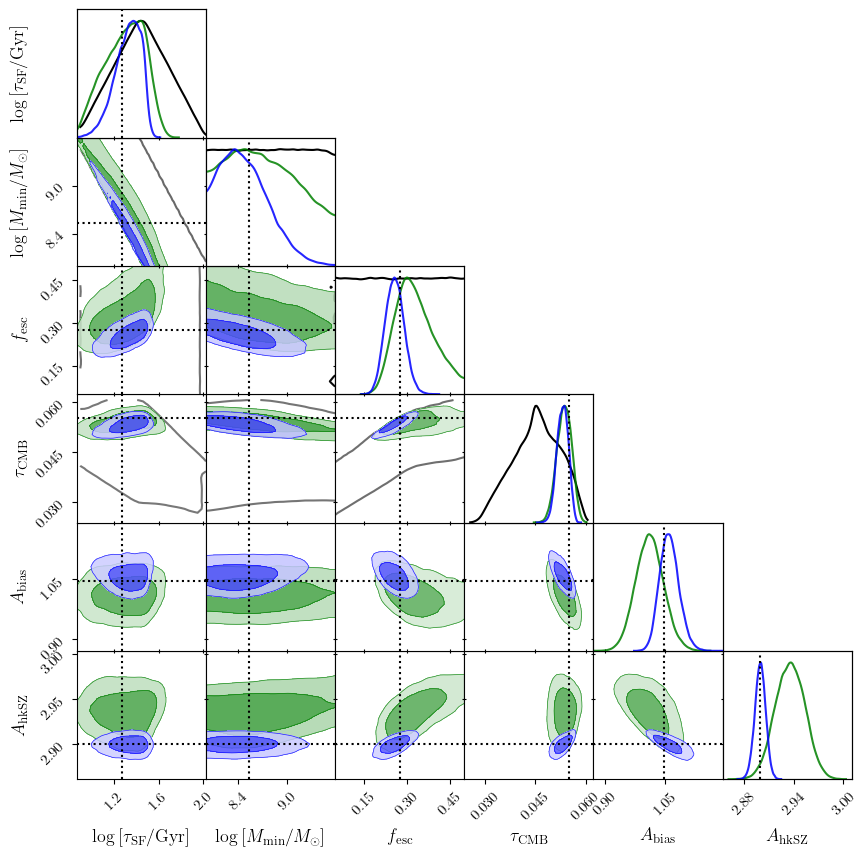

In [36]:
from anesthetic import read_chains, make_2d_axes
from anesthetic.samples import Samples

fig, axes = make_2d_axes(list(true_values.keys()), figsize=(10, 10), facecolor='w', upper=False)

samples = Samples(chainpriors, columns=list(small_dict.keys()))
samples.plot_2d(axes, kinds='kde', color='black', alpha=1.0, facecolor=None, levels=[0.99])

for i, chain in enumerate(chains):
    color = colors[i]
    # if i == 0:
    #     color = 'black'
    # elif i > 0:
    #     color = colors[i-1]
    chaintau = make_tauchains(chain[:,:3], A=False, dropA=False, truths=df.loc[config.sn].to_dict())
    chaintau = cp.deepcopy(np.concatenate([chaintau,chain[:,3:]], axis=1))
    chaintau[:,0] += -np.log10(1e2)

    # flattened_chain = utils.prior_flatten(samples, prior_hists)
    # flattened_chain[:,0] = flattened_chain[:,0] - np.log10(1e2)
    # flattened_stats = utils.get_weighted_stats(samples, prior_hists)
    
    # summarystats = summary_statistics(flattened_stats[0], 
    #                                     true_values.values(),
    #                                     flattened_stats[1], flattened_stats[2])

    # print(f"means: {flattened_stats[0]}")
    # print(f"CI are: {summarystats[1]}")
    # print(f"normalised biases are: {summarystats[0] / summarystats[1]}")
    samples = Samples(chaintau, columns=list(true_values.keys()))
    samples.plot_2d(axes, kinds='kde', color=colors[i], alpha=.85, levels=[.95, .68])#, label=list(true_values.values())[i])
  #  axes.iloc[-1, 0].legend(bbox_to_anchor=(len(axes)/2, len(axes)), loc='lower center', ncols=2)

# for i, p in enumerate(small_dict.keys()):
#     if i < 3:
#         axes[p][p].set_xlim(.95 * priors[2+i][0], 1.05 * priors[2+i][1])

axes.axlines(true_values, ls=':', c='k')
fig.savefig('corner.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)

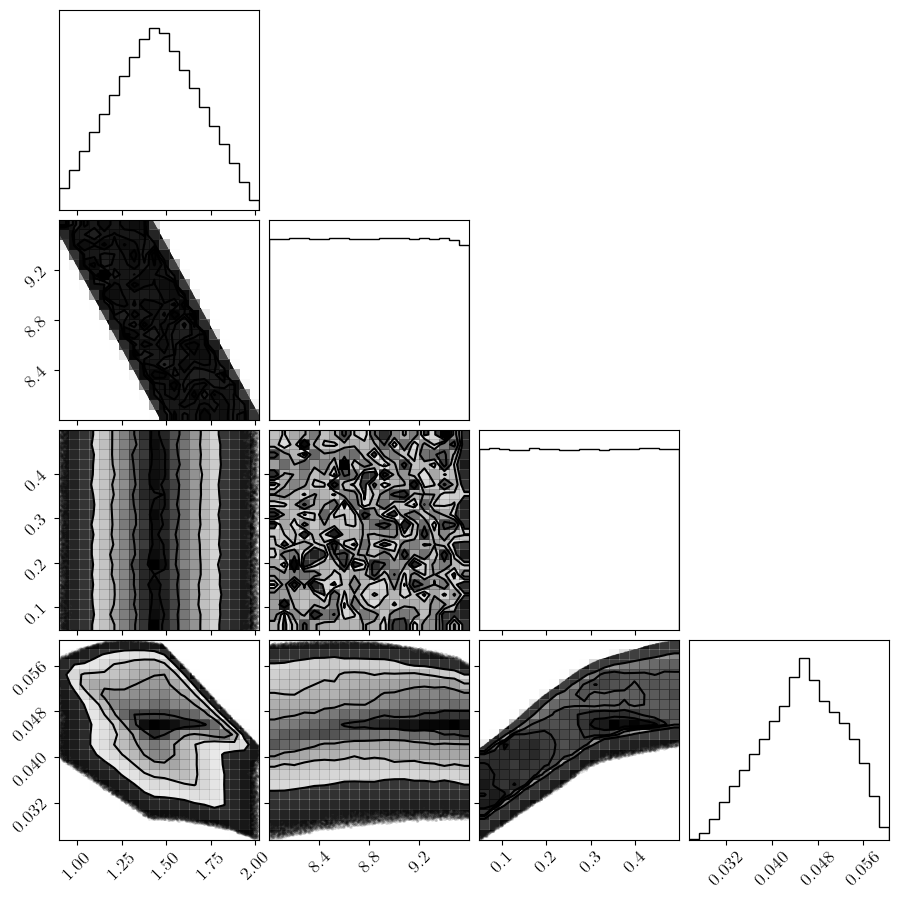

In [117]:
fig = corner.corner(chainpriors)

### Shaw2012 Template

In [149]:
mcmcdir = f"{base_dir}/inference/productionruns7_addhksz_Shaw2012"
survey_list = ['SO-LAT', 'CMB-S4', 'CMB-HD']
data = np.load(f"{mcmcdir}/{survey_list[2]}/noiseless/data.npz")

chains = []

# s, l = utils.load_samples(f"{base_dir}/inference/productionruns6_justpriors/CMB-HD/noiseless")
# chains.append(s)

# fig, ax = plt.subplots(1,3, figsize=(10,3))
# fig.subplots_adjust( wspace=0.0, hspace=0.0)

# norm = matplotlib.colors.Normalize(vmin=df["rHS"].min(), vmax=df["rHS"].max())
# cmap = plt.get_cmap('viridis_r')

# ztau = np.linspace(5,15,10)

for i, s in enumerate(survey_list):
    s, l = utils.load_samples(f"{mcmcdir}/{s}/noiseless")
    print(f"shape:", s.shape)
    chains.append(s)
    # params = fill(s, df.loc[config.sn].to_dict(), df.columns[2:])
    # xe = keras_xe_emul.xe_emul_array(ztau, params, plot=False)

    # for n in range(1,10000,1000):
    #     ax[i].semilogy(ztau, xe[n].T, color=cmap(norm(params[n,-1])))



Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns7_addhksz_Shaw2012/SO-LAT/noiseless...
shape: (120000, 5)
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns7_addhksz_Shaw2012/CMB-S4/noiseless...
shape: (120000, 5)
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns7_addhksz_Shaw2012/CMB-HD/noiseless...
shape: (120000, 5)


1.0053820096415385


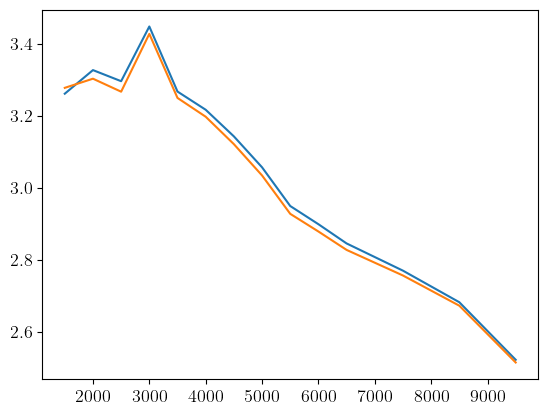

In [16]:
plt.plot(data['ells'], data['datapoints'])
plt.plot(data['ells'], data['model'])

print(np.mean(data['datapoints'] / data['model']))

/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))
/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))
/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


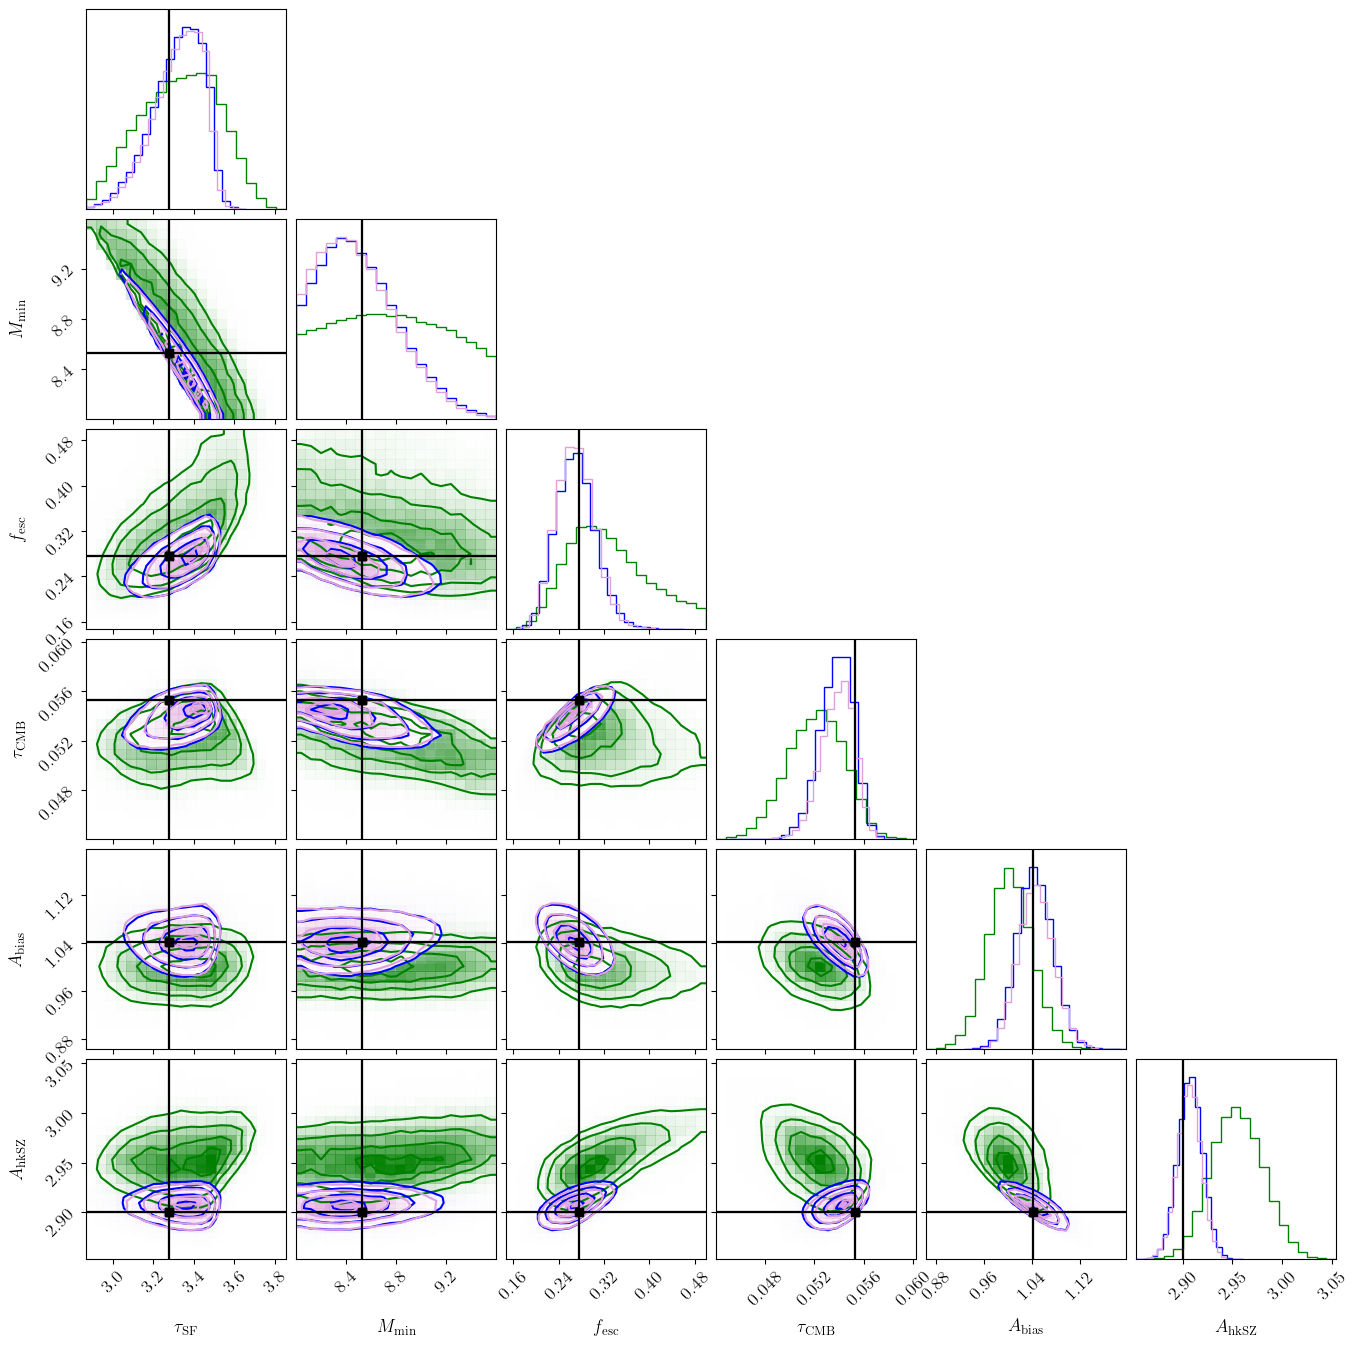

In [43]:
# pnames = [*df.columns[2:], 'tau_CMB', 'A', 'A_hksz']
pnames = ['$\\tau_{\\mathrm{SF}}$',
    '$M_{\\mathrm{min}}$',
    '$f_{\\mathrm{esc}}$',
    '$\\tau_{\\mathrm{CMB}}$',
    '$A_{\\mathrm{bias}}$',
    '$A_{\\mathrm{hkSZ}}$']

#true_params = [*df.loc[config.sn].to_numpy(), *whatthetau(df.loc[config.sn].to_numpy())]
#true_values = dict(zip(pnames, [*true_params[2:], np.mean(data['datapoints'] / data['model']), 2.9]))

cornerfig = None

for i, chain in enumerate(chains):
    color = colors[i]
    # if i == 0:
    #     color = 'black'
    # elif i > 0:
    #     color = colors[i-1]
    chaintau = make_tauchains(chain[:,:3], A=False, dropA=False, truths=df.loc[config.sn].to_dict())
    chaintau = cp.deepcopy(np.concatenate([chaintau, chain[:,3:]], axis=1))

    np.save(f'samples_wtau_{survey_list[i]}', chaintau)
    fig = corner.corner(chaintau, fig=cornerfig, color=color,
                        truth_color='black', truths=list(true_values.values()), labels=pnames,
                       plot_datapoints=False, plot_density=True)
    cornerfig = fig

#cornerfig.savefig('corner.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)

## A Giant Corner Plot

In [49]:
redshifts(xe_histories[config.sn]['z'], xe_histories[config.sn]['xe'])

(np.float64(7.642022944507361), np.float64(0.7506651008737153))

In [165]:
def redshifts(xe, z=np.linspace(20,5,100)):
    ion_fracs = [.25, .5, .75]

    z_tiled = np.tile(z, (xe.shape[0], 1))
    z_values = np.array([np.interp(ion_fracs, xe_row, z_tiled_row) for xe_row, z_tiled_row in zip(xe, z_tiled)])
    
    # Now z_values will have shape (N, 3), with z25, z50, z75 for each row in xe
    z25, z50, z75 = z_values[:, 0], z_values[:, 1], z_values[:, 2]
    duration = z25 - z75

    return z50, duration


true_z50, true_duration = redshifts(xe_histories[config.sn]['xe'][None,:], xe_histories[config.sn]['z'][None,:])
true_Dpksz = alfred.emulator.kemu(df.loc[config.sn].to_numpy(), mob)[3]
true_D3000 = true_Dpksz + 2.9

true_params = [*df.loc[config.sn].to_numpy(), *whatthetau(df.loc[config.sn].to_numpy())]
pnames = pnames = ['$\\tau_{\\mathrm{SF}}$',
    '$M_{\\mathrm{min}}$',
    '$f_{\\mathrm{esc}}$',
    '$\\tau_{\\mathrm{CMB}}$',
    '$A_{\\mathrm{bias}}$',
    '$A_{\\mathrm{hkSZ}}$',
    '$z_{50}$',
    '$\Delta z$',
    '$D_{3000}$',
    '$D_{\\mathrm{pksz}}$']
pvals = [*true_params[2:], np.mean(utils.spectra(config.sn)[indices] / alfred.emulator.kemu(df.loc[config.sn].to_numpy(), mob)),
                        2.9, true_z50, true_duration, true_D3000, true_Dpksz]
pvals = np.ravel(np.array(pvals, dtype=object)).astype(np.float64)
true_values = dict(zip(pnames, pvals))
   

<string>:38: RuntimeWarning: divide by zero encountered in log10
/var/folders/8t/k878xr_j2fqgy_993tg3qy7c0000gn/T/ipykernel_96902/3907074309.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pvals = np.ravel(np.array(pvals, dtype=object)).astype(np.float64)


In [162]:
true_values

{'$\\tau_{\\mathrm{SF}}$': np.float64(3.277127671229863),
 '$M_{\\mathrm{min}}$': np.float64(8.53),
 '$f_{\\mathrm{esc}}$': np.float64(0.275),
 '$\\tau_{\\mathrm{CMB}}$': np.float64(0.05526446348700878),
 '$A_{\\mathrm{bias}}$': np.float64(1.042532116516509),
 '$A_{\\mathrm{hkSZ}}$': np.float64(2.9),
 '$z_{50}$': np.float64(7.642022944507361),
 '$\\Delta z$': np.float64(0.7506651008737153),
 '$D_{3000}$': np.float64(3.42832350730896),
 '$D_{\\mathrm{pksz}}$': np.float64(0.5283233523368835)}

<string>:38: RuntimeWarning: divide by zero encountered in log10
<string>:38: RuntimeWarning: divide by zero encountered in log10
<string>:38: RuntimeWarning: divide by zero encountered in log10
python(96338) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(96339) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(96340) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(96341) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(96342) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(96343) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(96346) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(96353) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


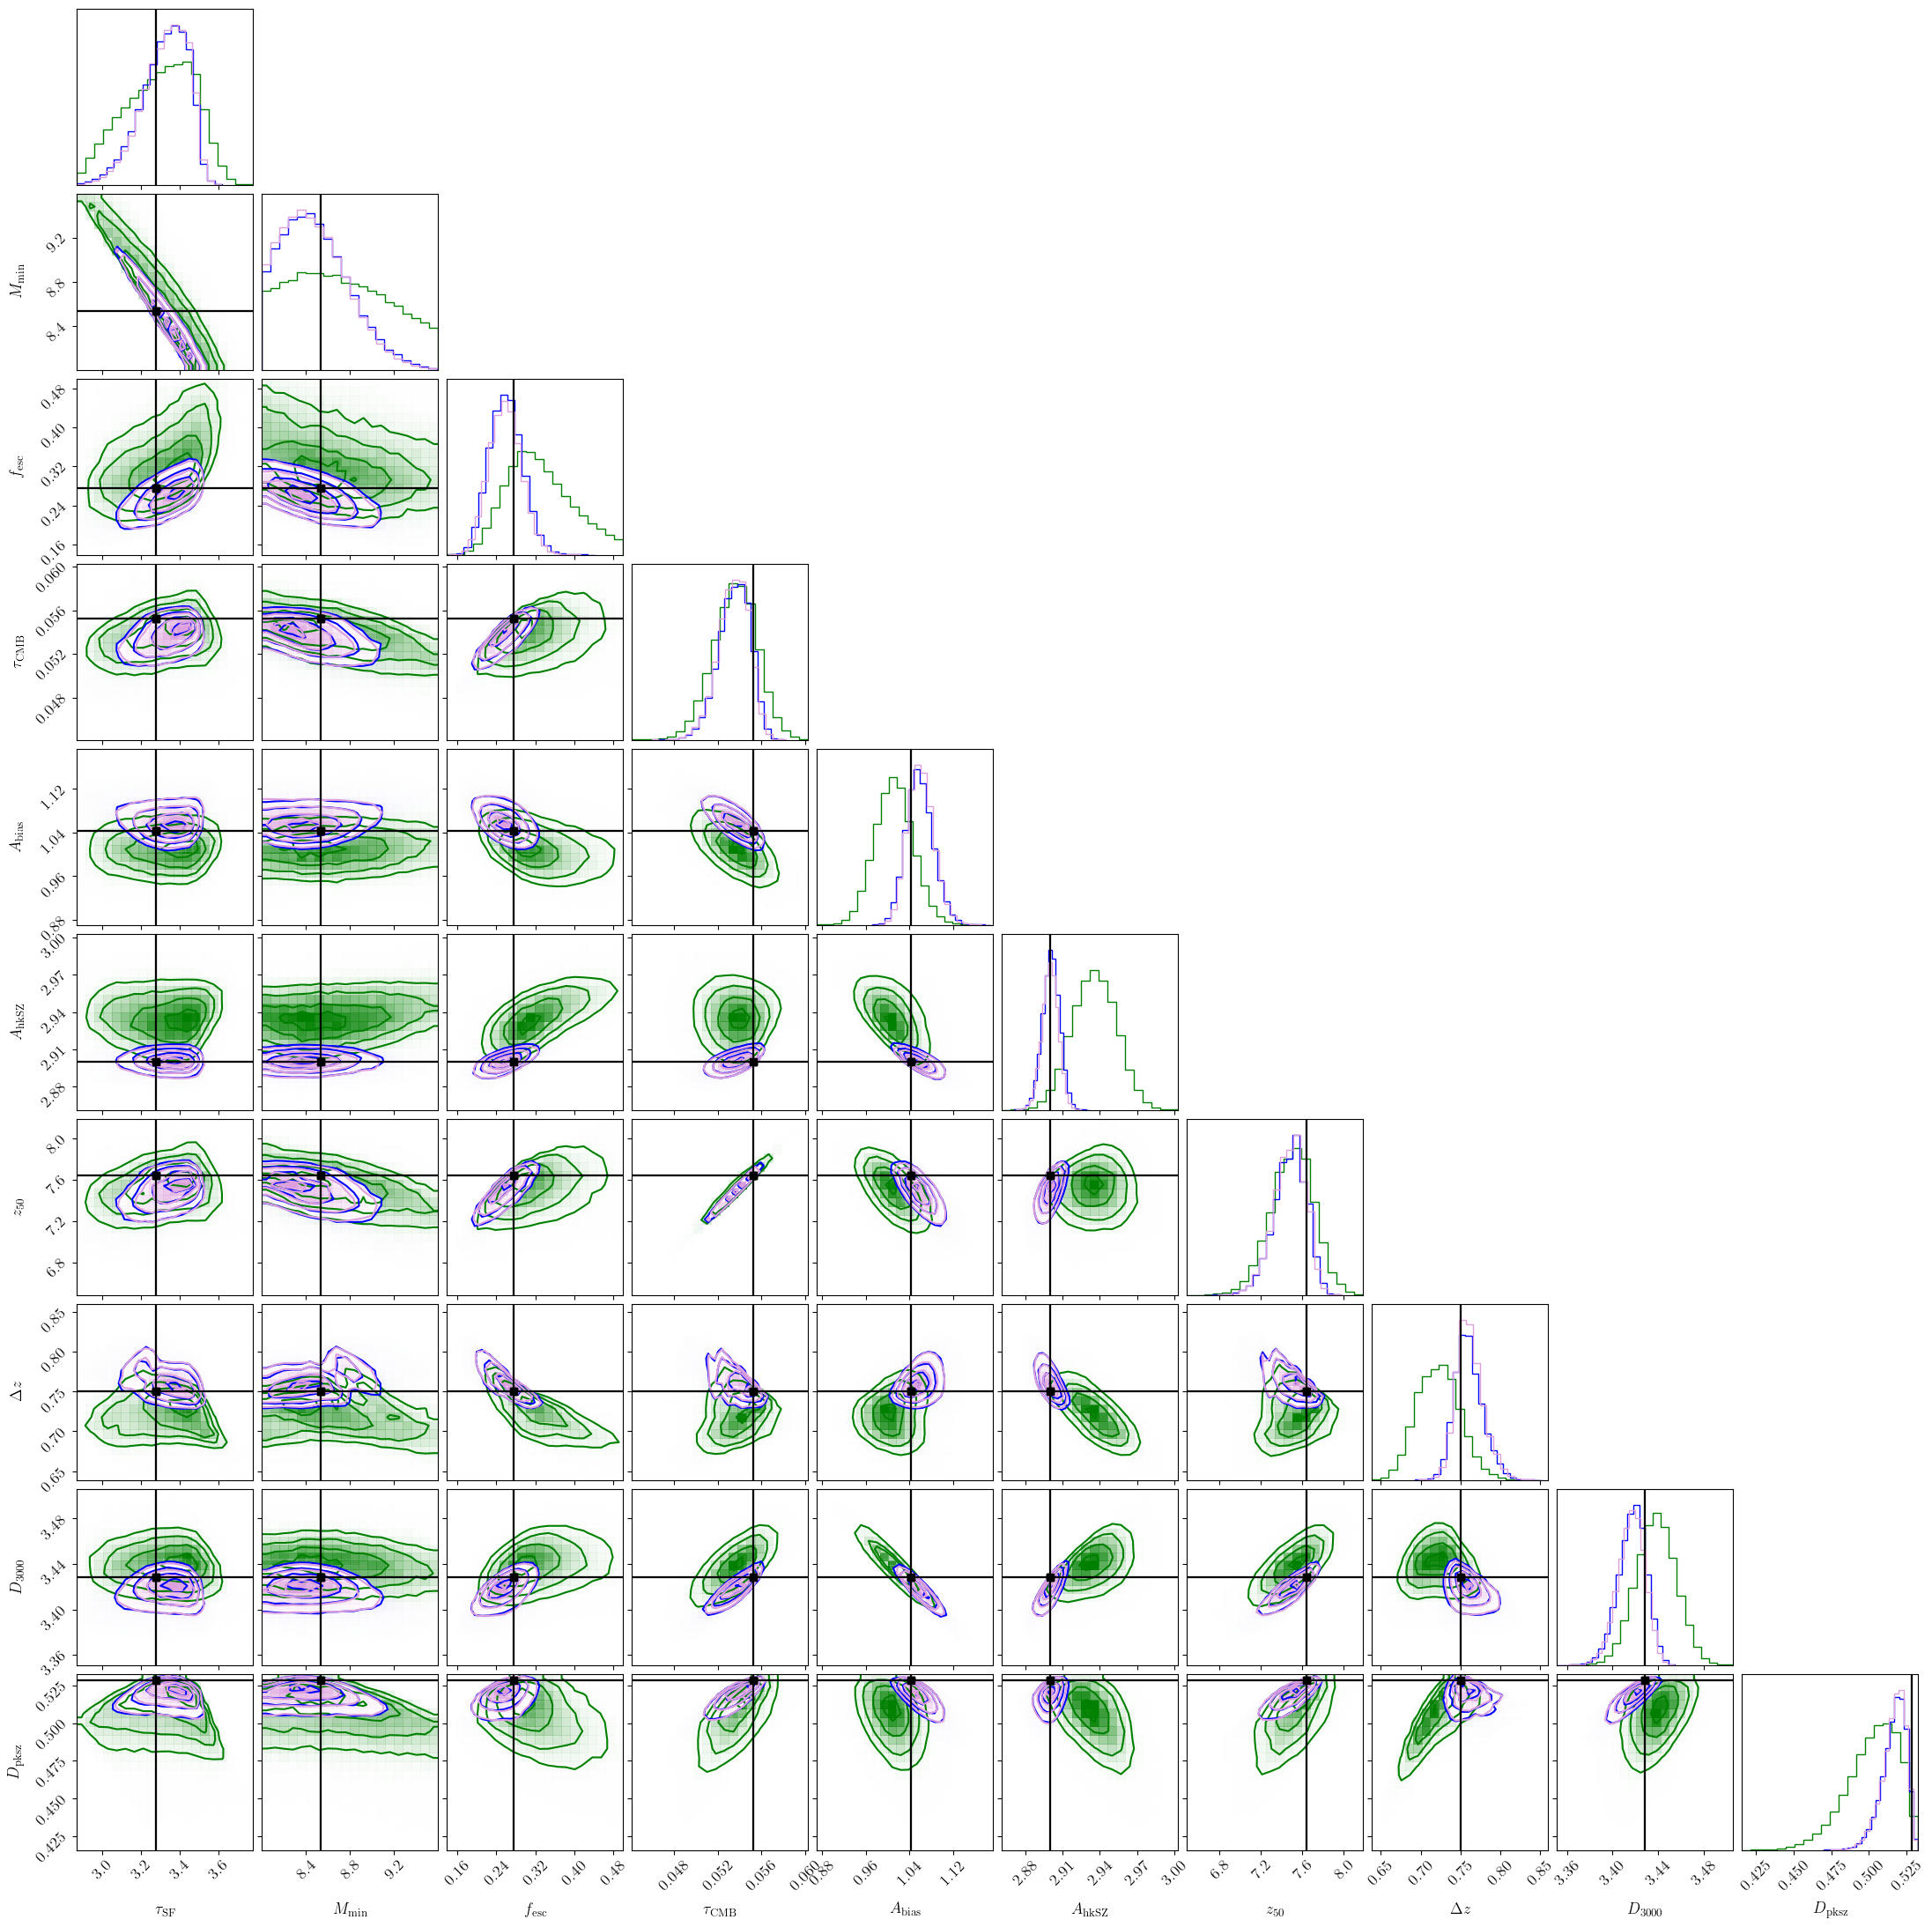

In [166]:
cornerfig = None

z = np.linspace(20,5,100)

samples_derived = []
for i, chain in enumerate(chains):
    color = colors[i]
    # if i == 0:
    #     color = 'black'
    # elif i > 0:
    #     color = colors[i-1]
    chaintau = make_tauchains(chain[:,:3], A=False, dropA=False, truths=df.loc[config.sn].to_dict())
    chaintau = cp.deepcopy(np.concatenate([chaintau, chain[:,3:]], axis=1))

    params = fill(chain[:,:3], df.loc[config.sn].to_dict())
    xemu = keras_xe_emul.xe_emul_array(z, params, plot=False, He1=False, He2=False)
    z50, duration = redshifts(xemu)

    signal = alfred.emulator.kemu(params, mob)
    D_pksz = signal[:,3]
    D_3000 = D_pksz + chaintau[:,-1]

    chaintau = cp.deepcopy(np.concatenate([chaintau, z50[:,None], duration[:,None], D_3000[:,None], D_pksz[:,None]], axis=1))
    samples_derived.append(chaintau)

    fig = corner.corner(chaintau, fig=cornerfig, color=color,
                        truth_color='black', truths=list(true_values.values()), labels=pnames,
                       plot_datapoints=False, plot_density=True)
    cornerfig = fig

In [167]:
for si, chains in enumerate(samples_derived):
    print('------------------------') 
    print(f'survey {survey_list[si]}')
    print('------------------------')
    for i, (pn, pv) in enumerate(true_values.items()):
        samples = chains[:,i]
        median_val = np.median(samples)
        
        # 68% credible interval (asymmetric)
        low, high = np.percentile(samples, [16, 84])
        low_err = median_val - low
        high_err = high - median_val
        
        # Bias and normalized bias
        bias = median_val - pv

        if bias <= 0.0:
            sigma_bias = low_err
        elif bias > 0.0:
            sigma_bias = high_err
        # sigma_68_sym = 0.5 * (high - low)  # for bias/σ, use symmetric approx
        bias_over_sigma = bias / sigma_bias

        print(f"for parameter {pn}")
        print(f"\t median : {median_val}")
        print(f"\t bias : {bias}")
        print(f"\t lowerr : {low_err}")
        print(f"\t higherr : {high_err}")
        print(f"\t bias / CI : {bias_over_sigma}")
        

------------------------
survey SO-LAT
------------------------
for parameter $\tau_{\mathrm{SF}}$
	 median : 3.3128772592236357
	 bias : 0.03574958799377281
	 lowerr : 0.21269546813874163
	 higherr : 0.16769379770977633
	 bias / CI : 0.2131837222485937
for parameter $M_{\mathrm{min}}$
	 median : 8.688892923637212
	 bias : 0.15889292363721275
	 lowerr : 0.447840229286399
	 higherr : 0.525266805962703
	 bias / CI : 0.30249945710160686
for parameter $f_{\mathrm{esc}}$
	 median : 0.32233941431313495
	 bias : 0.04733941431313493
	 lowerr : 0.05906822227894204
	 higherr : 0.07988209712163513
	 bias / CI : 0.5926160681667132
for parameter $\tau_{\mathrm{CMB}}$
	 median : 0.05364992575805113
	 bias : -0.0016145377289576504
	 lowerr : 0.0020691398899582783
	 higherr : 0.0018979443146348793
	 bias / CI : -0.78029413902518
for parameter $A_{\mathrm{bias}}$
	 median : 1.0108587312345598
	 bias : -0.031673385281949074
	 lowerr : 0.034190474177914876
	 higherr : 0.034912888327801817
	 bias / CI : -

### Posterior Comparison

## Appendix Plots

In [41]:
import os
import re

directory = f"{base_dir}/metadata/cuts"
pattern = re.compile(r".*\d{5}.*\.npz$")  # matches exact 5-digit numbers

fns = []
for filename in os.listdir(directory):
    if pattern.search(filename):
        fns.append(filename)

fns

['simu10539_cuts.npz',
 'simu10059_cuts.npz',
 'simu11933_cuts.npz',
 'simu14107_cuts.npz',
 'simu13646_cuts.npz',
 'simu15060_cuts.npz',
 'simu10528_cuts.npz',
 'simu12286_cuts.npz',
 'simu10835_cuts.npz',
 'simu10245_cuts.npz',
 'simu15042_cuts.npz',
 'simu12327_cuts.npz',
 'simu17099_cuts.npz',
 'simu10505_cuts.npz',
 'simu13873_cuts.npz',
 'simu11501_cuts.npz',
 'simu10324_cuts.npz',
 'simu12792_cuts.npz',
 'simu11174_cuts.npz',
 'simu12039_cuts.npz']

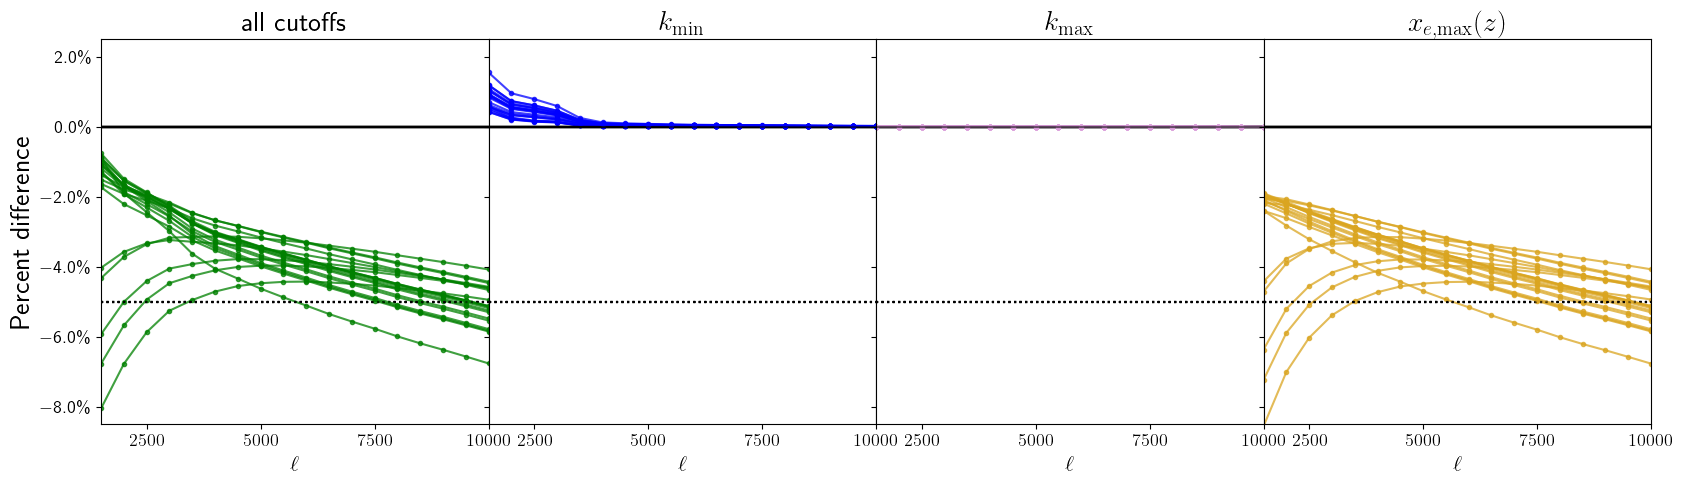

In [94]:
from matplotlib.ticker import PercentFormatter, LinearLocator, MultipleLocator

cuts = ['uncut',  'cut', 'kmin', 'kmax', 'xemax']
labels = ['all cutoffs', r'$k_{\mathrm{min}}$', r'$k_{\mathrm{max}}$', r'$x_{e,\mathrm{max}} (z)$']

fig, axes = plt.subplots(1,len(cuts[1:]), sharex=True, sharey=True, figsize=(20,5))
fig.subplots_adjust(wspace=0.0)

for fn in fns:
    kSZ = np.load(f"{base_dir}/cuts/{fn}", allow_pickle=True)


    for i, ax in enumerate(axes):

        ax.plot(ells, (kSZ[cuts[i+1]] - kSZ['uncut']) / kSZ['uncut'], color=colors[i], alpha=.75, marker='.', label=fn)

        ax.axhline(0.0, color='black', alpha=.5)

        ax.axhline(-.1, color='black', alpha=.1, ls=":")
        ax.axhline(.1, color='black', alpha=.1, ls=":")

        ax.axhline(-.05, color='black', alpha=.25, ls=":")
        ax.axhline(.05, color='black', alpha=.25, ls=":")

        ax.axvline(1000, color='green')
        ax.axvline(1000, color='green')

        ax.set_xlabel(r'$\ell$', fontsize=16)
        ax.set_title(f"{labels[i]}", fontsize=20)
#plt.legend()
        ax.set_xlim(1500, 10000)
        ax.set_ylim(-.085,.025)
        ax.xaxis.set_major_locator(MultipleLocator(2500))
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1)) 
axes[0].set_ylabel('Percent difference', fontsize=20)

fig.savefig('cuts.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)

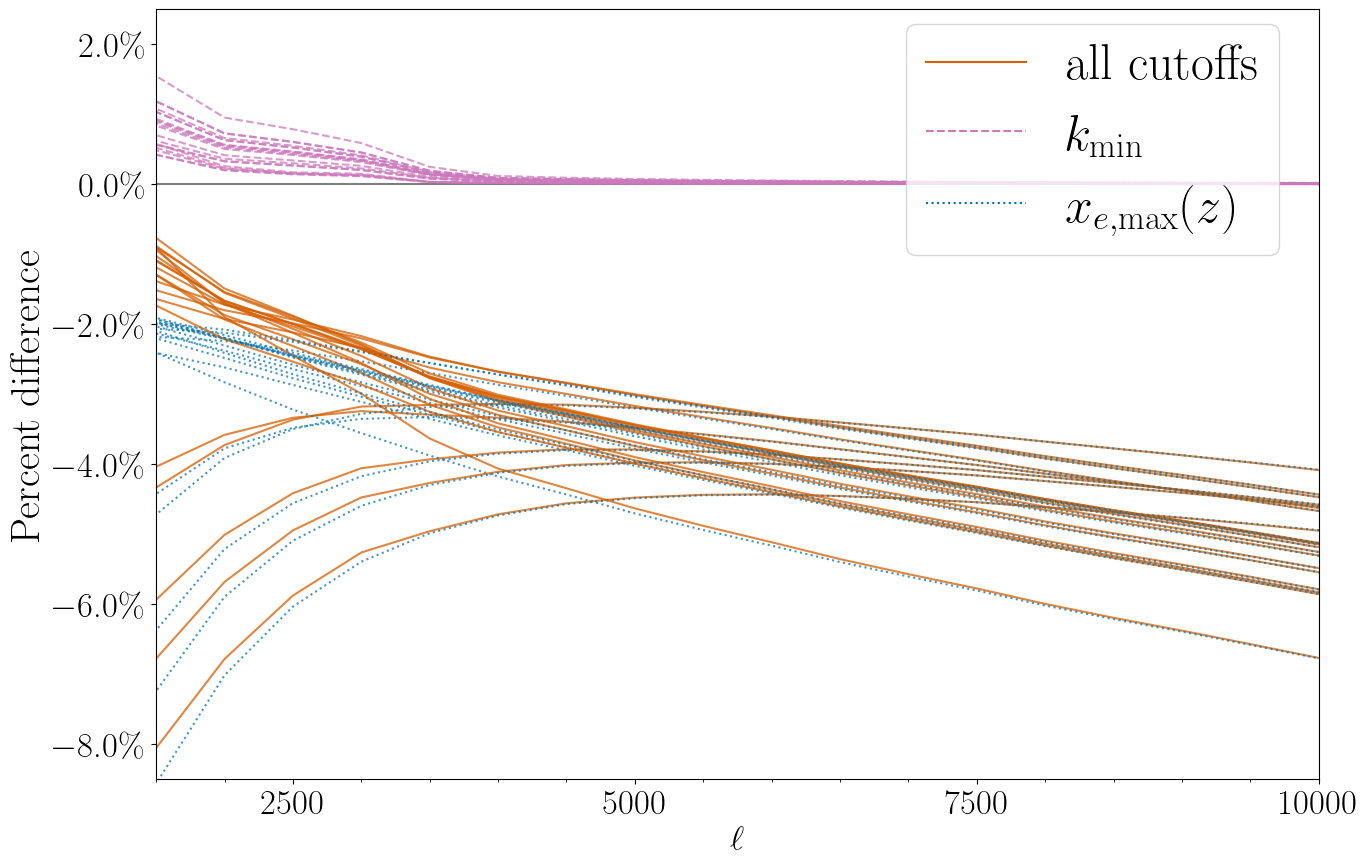

In [53]:
from matplotlib.ticker import PercentFormatter, LinearLocator, MultipleLocator

cuts = ['uncut',  'cut', 'kmin', 'xemax']
labels = ['all cutoffs', r'$k_{\mathrm{min}}$', r'$x_{e,\mathrm{max}} (z)$']

from matplotlib.lines import Line2D

linestyles = ['-', '--', ':']
cutcolors = ['#d55e00', '#cc78bc', '#0173b2'] #['#0173b2', '#de8f05', '#029e73']
legend_lines = []

for i in range(len(cuts[1:])):
    l = Line2D([0], [0], color=cutcolors[i], linestyle=linestyles[i], alpha=1.0, label=labels[i])
    legend_lines.append(l)

fig, ax = plt.subplots(figsize=(15,10))
fig.subplots_adjust(wspace=0.0)

ax.axhline(0.0, color='black', alpha=.5)


for fn in fns:
    kSZ = np.load(f"{base_dir}/metadata/cuts/{fn}", allow_pickle=True)

    for i, cut in enumerate(cuts[1:]):
        ax.plot(ells, (kSZ[cut] - kSZ['uncut']) / kSZ['uncut'],
                color=cutcolors[i], alpha=.75, ls=linestyles[i])


ax.set_xlabel(r'$\ell$', fontsize=25)

#plt.legend()
ax.set_xlim(1500, 10000)
ax.set_ylim(-.085,.025)
ax.xaxis.set_major_locator(MultipleLocator(2500))
ax.xaxis.set_minor_locator(MultipleLocator(500))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1)) 
ax.tick_params(axis='both', which='major', labelsize=25)  # major ticks
ax.tick_params(axis='both', which='minor', labelsize=20)  # minor ticks


fig.legend(handles=legend_lines, loc='upper right', fontsize=36, bbox_to_anchor=(.89, .89))
        
ax.set_ylabel('Percent difference', fontsize=30)

fig.savefig('cuts.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)

### Impact of 2D priors

In [19]:
Gaussian_samples = []

# sn = '11476'
sn = config.sn
# for p in np.mean(df.to_numpy(), axis=0)[2:]:
for p in df.loc[sn].to_numpy()[2:]:
    sp = np.random.normal(loc=p, scale=p*.1, size=120000)

    Gaussian_samples.append(sp)

Gaussian_samples = np.asarray(Gaussian_samples).T
tausamples = make_tauchains(Gaussian_samples, truths=df.loc[sn].to_dict(), A=False, dropA=False)

#print(samples.shape, psamples.shape)

/home/emc-brid/alfred/src/alfred/keras_xe_emul.py:174: RuntimeWarning: divide by zero encountered in log10
  np.log10(zvect),


In [20]:
passed2d = lnprob(Gaussian_samples, None, None, None, df.loc[sn].to_dict(), priors, Aprior=0.0,
            which_params=df.columns[2:], vectorize=True,
            priors2d=priors2d, add2d=True, justpriors=True,
            Planck=Planck, Planck_err=Planck_err, addPlanck=False,
            debug=False)

mask = np.isfinite(passed2d)

In [ ]:



samples = Samples(chainpriors, weights=None, columns=pnames[:-2])
samples.plot_2d(axes, kinds='kde', color='black', alpha=1.0, facecolor=None, levels=[0.99])

for i, chain in enumerate(chains):
    color = colors[i]
    # if i == 0:
    #     color = 'black'
    # elif i > 0:
    #     color = colors[i-1]
    chaintau = make_tauchains(chain[:,:3], A=False, dropA=False, truths=df.loc[config.sn].to_dict())
    chaintau = cp.deepcopy(np.concatenate([chaintau,chain[:,3:]], axis=1))
    chaintau[:,0] = chaintau[:,0] - np.log10(1e2)
    samples = Samples(chaintau, weights=None, columns=pnames)
    samples.plot_2d(axes, kinds='kde', color=colors[i], alpha=.85, levels=[.95, .68])#, label=list(true_values.values())[i])
  #  axes.iloc[-1, 0].legend(bbox_to_anchor=(len(axes)/2, len(axes)), loc='lower center', ncols=2)

axes.axlines(true_values, ls=':', c='k')
fig.savefig('corner.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)

In [21]:
from anesthetic import read_chains, make_2d_axes
from anesthetic.samples import Samples

tausamples[:,0] += -np.log10(1e2)

samples_noprior = Samples(tausamples, weights=None, columns=astro_wunits[2:6])
samples_2Dprior = Samples(tausamples[mask], weights=None, columns=astro_wunits[2:6])

ValueError: plot kind scatter can only be used for data frames

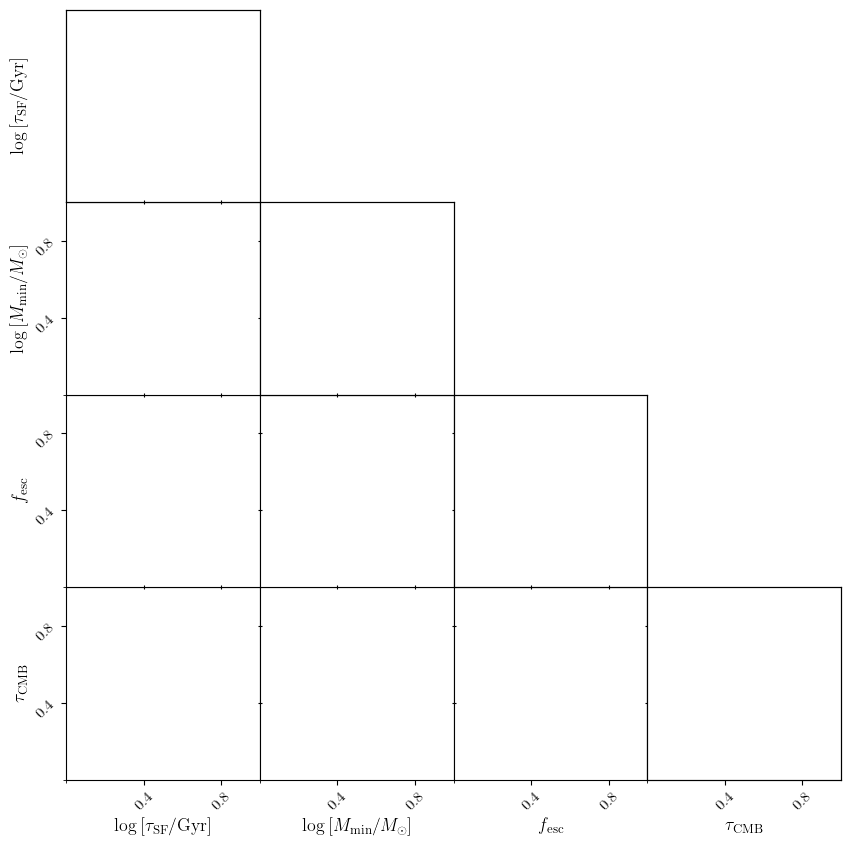

In [36]:
fig, axes = make_2d_axes(astro_wunits[2:6], figsize=(10, 10), facecolor='w', upper=False)

samples_noprior.plot_2d(axes, kinds=dict(diagonal='scatter', lower='scatter_2d'), color='black', alpha=.50)#, levels=[0.99])
samples_2Dprior.plot_2d(axes, kinds=dict(lower='scatter_2d'), color='green', alpha=1.0)#, levels=[0.99])
# samples_2Dprior.plot_2d(axes, kinds=dict(diagonal='hist_1d', lower='hist_2d'),
#                 lower_kwargs=dict(bins=30),
#                 diagonal_kwargs=dict(bins=20), color='green', alpha=1.0, facecolor=None)#, levels=[0.99])
#dict(diagonal='kde_1d', lower='kde_2d')

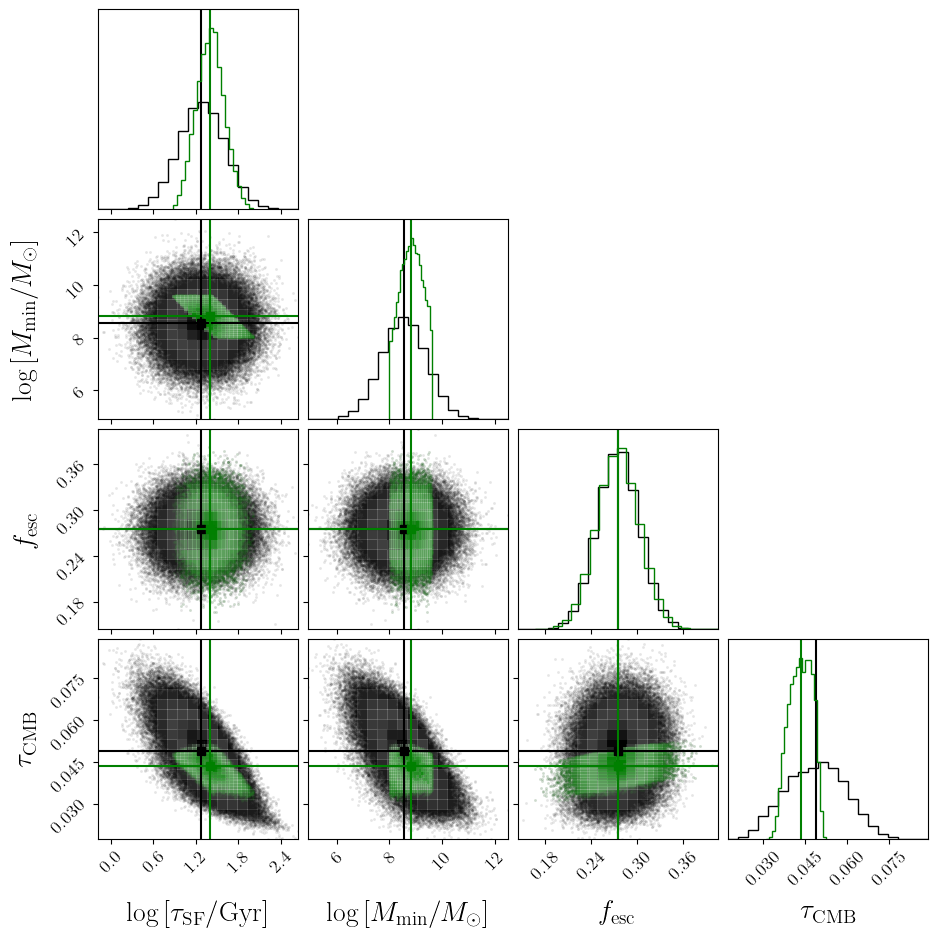

In [42]:
fig = corner.corner(tausamples, plot_contours=False, truths=np.median(tausamples, axis=0),
                    truth_color='black', no_fill_contours=True,
                    hist_kwargs={'density': True}, labels=astro_wunits[2:-1], label_kwargs={'fontsize':20})
fig = corner.corner(tausamples[mask], color='green', fig=fig, truths=np.median(tausamples[mask], axis=0),
                    truth_color='green',
                    plot_contours=False, no_fill_contours=True, hist_kwargs={'density': True})
# fig = corner.corner(tausim, color='red', fig=fig, truths=np.median(tausim, axis=0), truth_color='red',
#                     plot_contours=False, no_fill_contours=True, hist_kwargs={'density': True})

# axes = np.array(fig.axes).reshape((4, 4))
# plot_vlines(np.mean(tausamples[mask], axis=0), axes, color='deeppink')

for ax in fig.axes:
    for artist in ax.get_children():
        artist.set_rasterized(True)

fig.savefig('cornerbiases.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)